In [8]:
# ==============================================================================
# 🛠️ CELL 1: SETUP & CONFIGURATION
# ==============================================================================
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import shape
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import autogen
from dotenv import load_dotenv

# Import Overture Logic from Utl.py
try:
    from Utl import acs_county_data, process_locs_buildings
    print("Loaded Utl.py successfully.")
except ImportError:
    print("❌ Utl.py not found. Please ensure it is in the same folder.")

load_dotenv()
API_KEY = os.getenv("OPENAI_API_KEY", "")
API_BASE = "https://api.ai.it.cornell.edu/"

if not API_KEY:
    raise ValueError("OPENAI_API_KEY not found in .env file")

config_list = [
    {
        "model": "openai.gpt-5-mini", 
        "api_key": API_KEY, 
        "base_url": API_BASE
    },
    {
        "model": "meta.llama-4-maverick-17b-instruct", 
        "api_key": API_KEY, 
        "base_url": API_BASE
    },
    {
        "model": "google.gemini-2.5-flash", 
        "api_key": API_KEY, 
        "base_url": API_BASE
    },
    {
        "model": "xai.grok-3-mini", 
        "api_key": API_KEY, 
        "base_url": API_BASE
    },
]

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)

Loaded Utl.py successfully.


In [9]:
# ==============================================================================
# 📊 CELL 2: THE DEMOGRAPHER (ROBUST DATA INGESTION)
# ==============================================================================
class Demographer:
    def __init__(self):
        self.profiles = {} 

    def ingest_census(self, city_name, county_code, state_code):
        print(f"\n📥 [DEMOGRAPHER] Fetching Real ACS Data for {city_name}...")
        
        # 1. Fetch from Census API
        try:
            acs_county_data(county_code, state_code) # Saves to CSV
        except Exception as e:
            print(f"   ⚠️ API Warning: {e} (Attempting to read cached CSV)")

        # 2. Process Data
        fpath = f"ACS/{state_code}_{county_code}.csv"
        if os.path.exists(fpath):
            df = pd.read_csv(fpath)
            
            # Find Age Column dynamically based on mapping
            col_age = next((c for c in df.columns if 'Age' in c or 'B01002' in c), None)
            
            if col_age:
                # --- FIX: Handle Sparse Data ---
                if len(df) < 17:
                    # Upsample if not enough tracts to fill the grid
                    df = df.sample(n=17, replace=True).reset_index(drop=True)
                    df['zone_id'] = [f"Region {i}" for i in range(17)]
                else:
                    # Use pd.cut (Equal Interval) instead of qcut to prevent bin errors
                    df = df.sort_values(by=col_age).reset_index(drop=True)
                    df['zone_id'] = pd.cut(df.index, bins=17, labels=[f"Region {i}" for i in range(17)])

                grouped = df.groupby('zone_id')[[col_age]].mean()
                
                # Assign Sociological Cohort
                def get_cohort(age):
                    if pd.isna(age): return "Family"
                    if age < 34: return "Young Urban"
                    elif age < 48: return "Family"
                    else: return "Senior"
                
                grouped['cohort'] = grouped[col_age].apply(get_cohort)
                self.profiles[city_name] = grouped.to_dict('index')
                print(f"   ✅ Mapped {len(grouped)} zones to cohorts using Real Census Data.")
                return self.profiles[city_name]
        
        print("   ❌ Failed. Check ACS/ folder or API Key.")
        return {}

demo = Demographer()

In [10]:
# ==============================================================================
# 🧠 CELL 3: THE SOCIOLOGIST (INTENT GENERATION)
# ==============================================================================
class SociologistAgent:
    def __init__(self, model_cfg=None):
        # FIX: Added code_execution_config=False to prevent Docker error
        llm_cfg = {"config_list": [model_cfg] if model_cfg else config_list}
        self.agent = autogen.AssistantAgent("Sociologist", llm_config=llm_cfg, system_message="JSON Only.")
        self.user = autogen.UserProxyAgent(
            "user", 
            human_input_mode="NEVER", 
            max_consecutive_auto_reply=0,
            code_execution_config=False  # <--- THIS FIXES THE ERROR
        )
        self.schedules = {} 

    def generate_schedules(self, city_name, profiles):
        if not profiles: return {}
        cohorts = set(p['cohort'] for p in profiles.values())
        print(f"\n🧠 [SOCIOLOGIST] Modeling Lifestyles for {len(cohorts)} Cohorts...")
        
        for cohort in cohorts:
            prompt = f"""
            Context: {city_name}. Demographic: '{cohort}'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {{"0": {{"sleep": 0.9, ...}}, ...}}
            """
            try:
                res = self.user.initiate_chat(self.agent, message=prompt)
                data = json.loads(res.chat_history[-1]['content'].replace("```json","").replace("```","").strip())
                self.schedules[f"{city_name}_{cohort}"] = data
            except: pass
        return self.schedules

soc = SociologistAgent()

In [ ]:
# ==============================================================================
# 🚦 CELL 4: THE MOBILITY PLANNER (REASONING ENGINE)
# ==============================================================================
class MobilityPlanner:
    def __init__(self, model_cfg=None):
        # FIX: Added code_execution_config=False here too
        llm_cfg = {"config_list": [model_cfg] if model_cfg else config_list}
        self.agent = autogen.AssistantAgent("Planner", llm_config=llm_cfg, system_message="Output JSON.")
        self.user = autogen.UserProxyAgent(
            "user", 
            human_input_mode="NEVER", 
            max_consecutive_auto_reply=0,
            code_execution_config=False
        )
        self.cache = {}

    def decide_forces(self, city_name, hour, day_type, schedules):
        cache_key = f"{city_name}_{day_type}_{hour}"
        if cache_key in self.cache: return self.cache[cache_key]
        
        # Aggregate City State
        summary = []
        for key, sched in schedules.items():
            if city_name in key:
                cohort = key.split('_')[1]
                acts = sched.get(str(hour), {})
                top = max(acts, key=acts.get)
                summary.append(f"{cohort}: {top} ({acts[top]:.2f})")
        context_str = "; ".join(summary)

        print(f"   🧠 [PLANNER] Reasoning for {city_name} @ {hour}:00...")
        
        prompt = f"""
        City: {city_name}, {day_type}, Hour {hour}.
        State: {context_str}.
        Task: 
        1. Analyze cultural/temporal drivers.
        2. Output 3 'Mobility Forces' (0.0-1.0).
        Output JSON: {{"reasoning": "...", "forces": {{"commute": <float>, "leisure": <float>, "home": <float>}}}}
        """
        try:
            res = self.user.initiate_chat(self.agent, message=prompt)
            data = json.loads(res.chat_history[-1]['content'].replace("```json","").replace("```","").strip())
            
            # --- PROOF OF THINKING ---
            print(f"      💭 Logic: {data['reasoning']}") 
            
            self.cache[cache_key] = data['forces']
            return data['forces']
        except:
            return {"commute": 0.3, "leisure": 0.3, "home": 0.3}

plan = MobilityPlanner()

In [ ]:
# ==============================================================================
# 🚀 CELL 5: HARD DATA ENGINE (DYNAMIC & MULTI-CITY)
# ==============================================================================
class HardDataEngine:
    def __init__(self, city_name, sociologist, planner):
        self.city_name = city_name
        self.soc = sociologist
        self.plan = planner
        self.coords = {}
        self.zones = []
        self.building_data = {} 
        self.model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
        self.scaler = StandardScaler()

    def ingest_buildings_dynamic(self, bbox, geojson_path):
        """Fetches Real Buildings for ANY city based on BBox."""
        print(f"\n🏗️ [ENGINE] Fetching Overture Data for {self.city_name}...")
        try:
            # 1. Fetch Buildings using Utl logic but dynamic coords
            locs = {self.city_name: bbox} 
            gdf_buildings = process_locs_buildings(locs)
            
            # 2. Load City Zones
            with open(geojson_path, 'r') as f:
                geojson = json.load(f)
            
            polygons = [shape(feat["geometry"]) for feat in geojson["features"]]
            gdf_shapes = gpd.GeoDataFrame(
                {"shape_id": list(range(len(polygons)))},
                geometry=polygons,
                crs="EPSG:4326"
            )

            # 3. Spatial Join
            joined = gpd.sjoin(gdf_buildings, gdf_shapes, how="inner", predicate="within")

            # 4. Aggregate
            agg = joined.groupby(["shape_id", "subtype"]).agg(
                total_capacity=("capacity", "sum")
            ).reset_index()

            for _, row in agg.iterrows():
                sid = f"Region {int(row['shape_id'])}"
                if sid not in self.building_data: 
                    self.building_data[sid] = {'residential': 0, 'commercial': 0}
                
                subtype = str(row['subtype']).lower()
                cap = float(row['total_capacity'])
                
                if subtype in ['residential', 'apartments']:
                    self.building_data[sid]['residential'] += cap
                else:
                    self.building_data[sid]['commercial'] += cap
            
            print(f"   ✅ Spatially Joined buildings into {len(self.building_data)} zones.")

        except Exception as e:
            print(f"   ⚠️ Spatial Error: {e} (Using Fallback Density)")
            self.building_data = {f"Region {i}": {'residential': 1000, 'commercial': 1000} for i in range(17)}

    def learn_topology(self, files):
        print(f"   🗺️ [TOPOLOGY] Learning Functional Map (MDS)...")
        flows = {}
        all_zones = set()
        for fp in files:
            try:
                df = pd.read_csv(fp)
                if 'flow_count' not in df.columns: df['flow_count'] = df.filter(like='Trips').sum(axis=1)
                for _, row in df.iterrows():
                    o, d, f = str(row['Origin']).strip(), str(row['Destination']).strip(), row['flow_count']
                    flows[(o,d)] = flows.get((o,d), 0) + f
                    all_zones.add(o); all_zones.add(d)
            except: pass
        self.zones = sorted(list(all_zones))
        if not self.zones: return False
        
        n = len(self.zones)
        dist_matrix = np.ones((n, n)) * 100.0
        max_flow = max(flows.values()) if flows else 1
        for (o, d), f in flows.items():
            if o in self.zones and d in self.zones:
                i, j = self.zones.index(o), self.zones.index(d)
                m = 1.0 - (f / max_flow)
                dist_matrix[i, j] = m; dist_matrix[j, i] = m
        np.fill_diagonal(dist_matrix, 0)
        
        mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress=False)
        tx = mds.fit_transform(dist_matrix)
        for i, z in enumerate(self.zones): self.coords[z] = tx[i]
        return True

    def _prepare(self, files):
        X, y = [], []
        for fp in files:
            if not os.path.exists(fp): continue
            hour = 12
            match = re.search(r"(\d+)-(\d+)", fp)
            if match: hour = int(match.group(1))
            day_type = "Weekend" if "10-13" in fp else "Weekday"
            
            forces = self.plan.decide_forces(self.city_name, hour, day_type, self.soc.schedules)
            
            try:
                df = pd.read_csv(fp)
                if 'flow_count' not in df.columns: df['flow_count'] = df.filter(like='Trips').sum(axis=1)
                for _, row in df.iterrows():
                    o, d = str(row['Origin']).strip(), str(row['Destination']).strip()
                    if o not in self.coords or d not in self.coords or o==d: continue
                    
                    # 1. Physics (MDS Distance)
                    dist = np.linalg.norm(self.coords[o] - self.coords[d])
                    # 2. Hard Data (Overture Density)
                    dest_comm = self.building_data.get(d, {}).get('commercial', 100) 
                    dest_res = self.building_data.get(d, {}).get('residential', 100)
                    # 3. Soft Data (Agent Forces)
                    feat = [dist, dest_comm, dest_res, hour, 1 if day_type=="Weekday" else 0,
                            forces['commute'], forces['leisure'], forces['home']]
                    
                    X.append(feat)
                    y.append(row['flow_count'])
            except: pass
        return np.array(X), np.array(y)

    def train_and_test(self, train_files, test_file):
        X_train, y_train = self._prepare(train_files)
        if len(X_train) == 0: return 0, [], []
        
        print(f"   ⚙️ [ML] Training on {len(X_train)} samples...")
        self.model.fit(self.scaler.fit_transform(X_train), y_train)
        
        X_test, y_true = self._prepare([test_file])
        if len(X_test) == 0: return 0, [], []
        y_pred = np.maximum(self.model.predict(self.scaler.transform(X_test)), 0)
        
        return r2_score(y_true, y_pred), y_true, y_pred

In [13]:
# ==============================================================================
# 📸 CELL 6: VISUALIZATION SUITE (FIGURES 1-4)
# ==============================================================================
def plot_results(city_name, engine, r2, y_true, y_pred, sociologist):
    print(f"\ngenerating Plots for {city_name}...")
    
    # 1. Activity Schedules
    activities = ['work', 'leisure']
    fig1, axes = plt.subplots(1, 2, figsize=(12, 4))
    hours = range(24)
    for i, act in enumerate(activities):
        ax = axes[i]
        for key, sched in sociologist.schedules.items():
            if city_name in key:
                cohort = key.split('_')[1]
                probs = [sched.get(str(h), {}).get(act, 0) for h in hours]
                ax.plot(hours, probs, label=cohort, linewidth=2)
        ax.set_title(f"{act.title()} Patterns")
        if i==0: ax.legend()
    plt.show()

    # 2. Topology & Accuracy
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    coords = np.array(list(engine.coords.values()))
    ax1.scatter(coords[:,0], coords[:,1], c='purple', s=100, alpha=0.6)
    for i, txt in enumerate(engine.coords.keys()):
        ax1.text(coords[i,0], coords[i,1], txt, fontsize=8)
    ax1.set_title(f"Latent Map (MDS)")
    
    ax2.scatter(y_true, y_pred, alpha=0.5, color='teal')
    ax2.plot([0, max(y_true)], [0, max(y_true)], 'r--')
    ax2.set_title(f"Accuracy (R²={r2:.3f})")
    ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
    plt.show()

    # 3. Flow Shift (Morning vs Night)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    for ax, hour in [(ax1, 8), (ax2, 22)]:
        forces = {"commute":0.9,"leisure":0.1,"home":0.1} if hour==8 else {"commute":0.1,"leisure":0.9,"home":0.9}
        X_viz, pairs = [], []
        for o in engine.zones:
            for d in engine.zones:
                if o==d: continue
                dist = np.linalg.norm(engine.coords[o]-engine.coords[d])
                feat = [dist, 100, 100, hour, 1, forces['commute'], forces['leisure'], forces['home']]
                X_viz.append(feat)
                pairs.append((engine.coords[o], engine.coords[d]))
        flows = engine.model.predict(engine.scaler.transform(X_viz))
        max_f = max(flows)
        
        c = np.array(list(engine.coords.values()))
        ax.scatter(c[:,0], c[:,1], color='lightgrey', s=50)
        for i, (p1, p2) in enumerate(pairs):
            if flows[i] > max_f*0.2:
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='blue' if hour==8 else 'red', alpha=flows[i]/max_f)
        ax.set_title(f"Hour {hour}: {'Commute' if hour==8 else 'Leisure'} Flow")
        ax.axis('off')
    plt.suptitle(f"Agent-Driven Flow Shift ({city_name})")
    plt.show()


🏙️  STARTING BENCHMARK: NYC

📥 [DEMOGRAPHER] Fetching Real ACS Data for NYC...
   ✅ Mapped 17 zones to cohorts using Real Census Data.

   🤖 MODEL: openai.gpt-5-mini...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: NYC. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
Sociologist (to user):

{
  "0": {"sleep": 0.92, "work": 0.00, "leisure": 0.02, "home": 0.06},
  "1": {"sleep": 0.95, "work": 0.00, "leisure": 0.02, "home": 0.03},
  "2": {"sleep": 0.95, "work": 0.00, "leisure": 0.01, "home": 0.04},
  "3": {"sleep": 0.93, "work": 0.00, "leisure": 0.01, "home": 0.06},
  "4": {"sleep": 0.85, "work": 0.00, "leisure": 0.02, "home": 0.13},
  "5": {"sleep": 0.60, "work": 0.01, "leisure": 0.12, "home": 0

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Planner (to user):

{"reasoning":"Weekday 06:00 in NYC is early-morning, pre-peak rush: overall city mobility is ramping up but not yet at full weekday commute levels. Cultural drivers: NYC’s 24/7 transit and early-opening coffee shops/parks encourage morning outdoor/leisure activity (walks, social coffee, light exercise), which is attractive to many seniors who favor quieter early hours and predictable routines. Temporal drivers: before the main 7–9am commuter surge, seniors are less likely to undertake work-style commuting but often leave home for leisure, medical appointments, errands, or transit connections; mobility is moderated by health/mobility constraints and safety/lighting considerations. Given the provided senior leisure baseline (0.35), the remaining mass is allocated to a modest commute component (reflecting errands/appointments and some early workers) and a larger home/stay component (rest, preparation, or deferred travel until later peak).","forces":{"commute":0.2,"leis

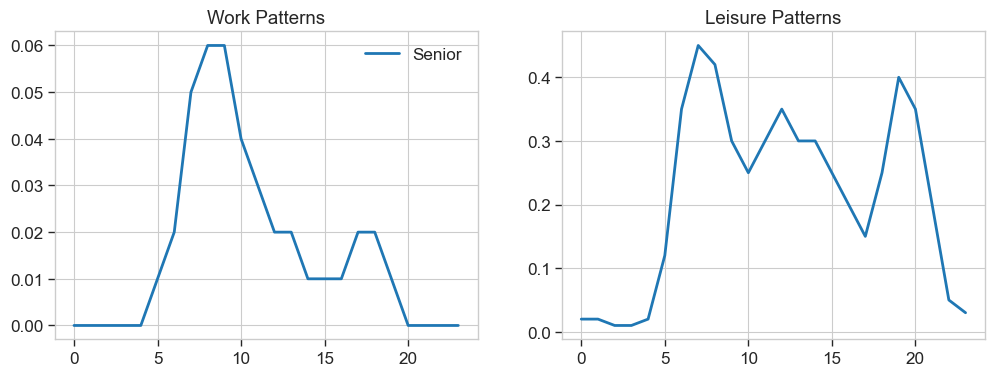

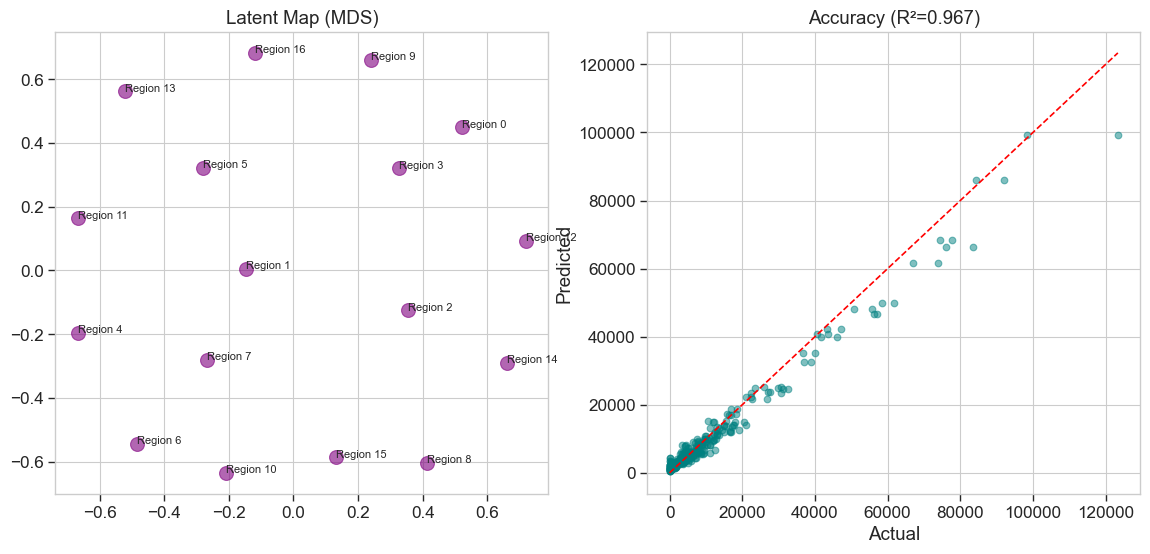

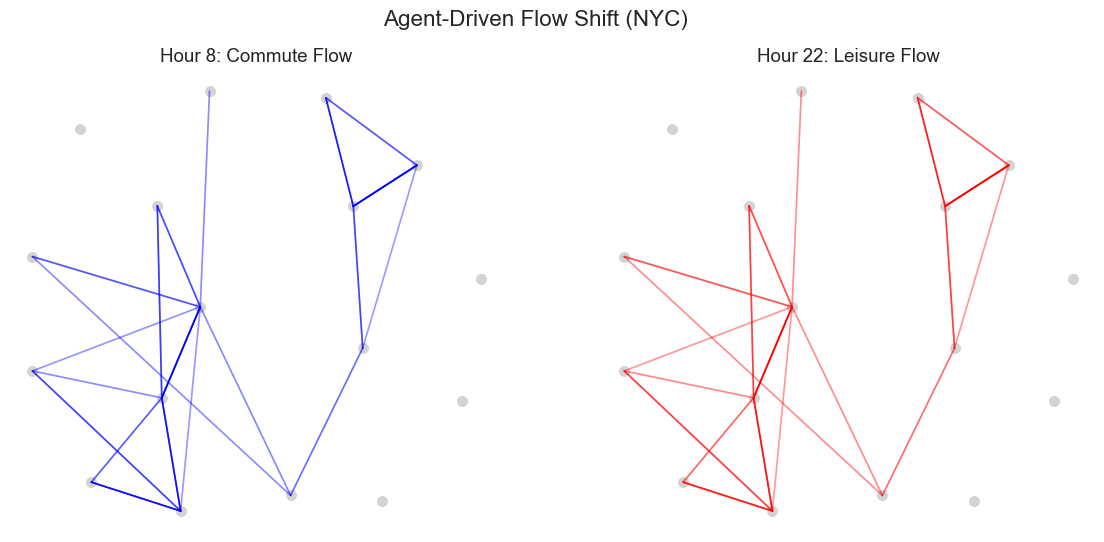


   🤖 MODEL: meta.llama-4-maverick-17b-instruct...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: NYC. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 10:41:09] {704} WARNING - Model us.meta.llama4-maverick-17b-instruct-v1:0 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

```json
{
  "0": {"sleep": 0.95, "work": 0.01, "leisure": 0.03, "home": 0.99},
  "1": {"sleep": 0.96, "work": 0.01, "leisure": 0.02, "home": 0.99},
  "2": {"sleep": 0.97, "work": 0.01, "leisure": 0.01, "home": 0.99},
  "3": {"sleep": 0.98, "work": 0.01, "leisure": 0.01, "ho

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 10:41:14] {704} WARNING - Model us.meta.llama4-maverick-17b-instruct-v1:0 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

To analyze the given scenario and output the required JSON, let's break down the information and the task step by step.

1. **City: NYC, Weekday, Hour 6.**
   - This setting indicates it's early morning on a weekday in New York City, a bustling metropolis known for its dense population and fast-paced lifestyle. Hour 6 is typically around the time people start their day, with many likely getting ready for work or school.

2. **State: Senior: home (0.80).**
   - The individual in question is a senior, and there's an 80% likelihood they are at home. This suggests that the senior is likely retired or not working regular hours, which is common for many seniors.

3. **Task: 
   1. Analyze cultural/temporal drivers.
   2. 

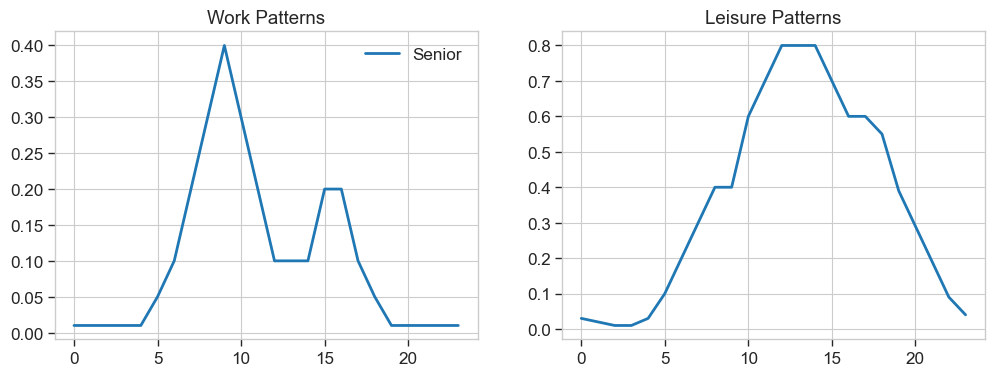

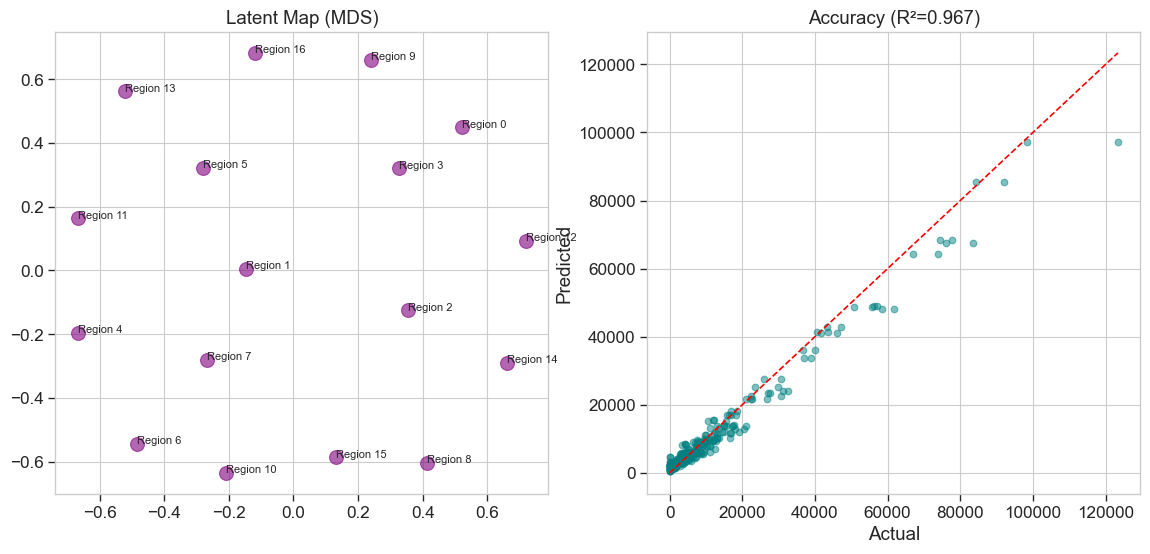

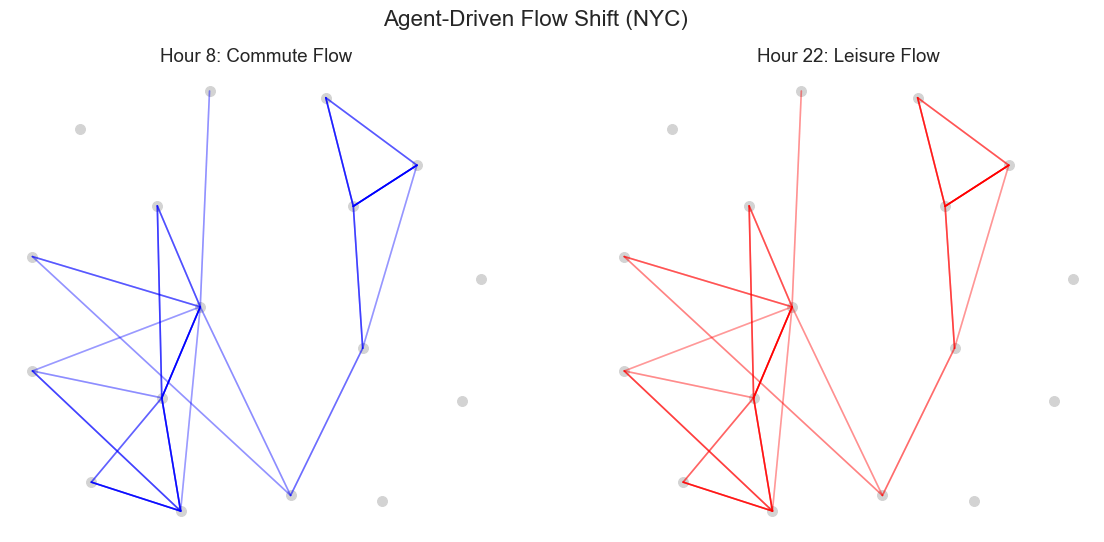


   🤖 MODEL: google.gemini-2.5-flash...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: NYC. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 10:42:13] {704} WARNING - Model gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

```json
{
  "0": {
    "sleep": 0.95,
    "work": 0.0,
    "leisure": 0.05,
    "home": 1.0
  },
  "1": {
    "sleep": 0.97,
    "work": 0.0,
    "leisure": 0.03,
    "home": 1.0
  },
  "2": {
    "sleep": 0.97,
    "work": 0.0,
    "leisure": 0.03,
    "home": 1.0
  },
  "3": {
    "sleep": 0.97,
    "work":

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 10:42:24] {704} WARNING - Model gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

```json
{
  "reasoning": "At 6 AM on a weekday in NYC, a senior is highly likely to be at home, as indicated by the initial state (0.98 probability of being home). This early hour is typically associated with morning routines like waking up, breakfast, or light activities within the home. Commuting for seniors at 6 AM is rare, and external leisure activities are generally not a primary driver at this time. Therefore, the force to remain home is dominant.",
  "forces": {
    "commute": 0.02,
    "leisure": 0.03,
    "home": 0.95
  }
}
```

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (0dbf9afd-d5d9-44a6-a921-abf1f681c135): Maximum number of consecutive auto-replies reached
      💭

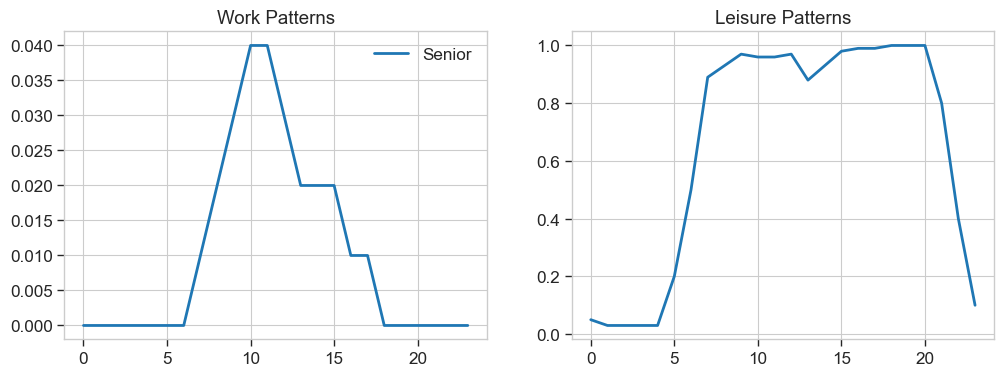

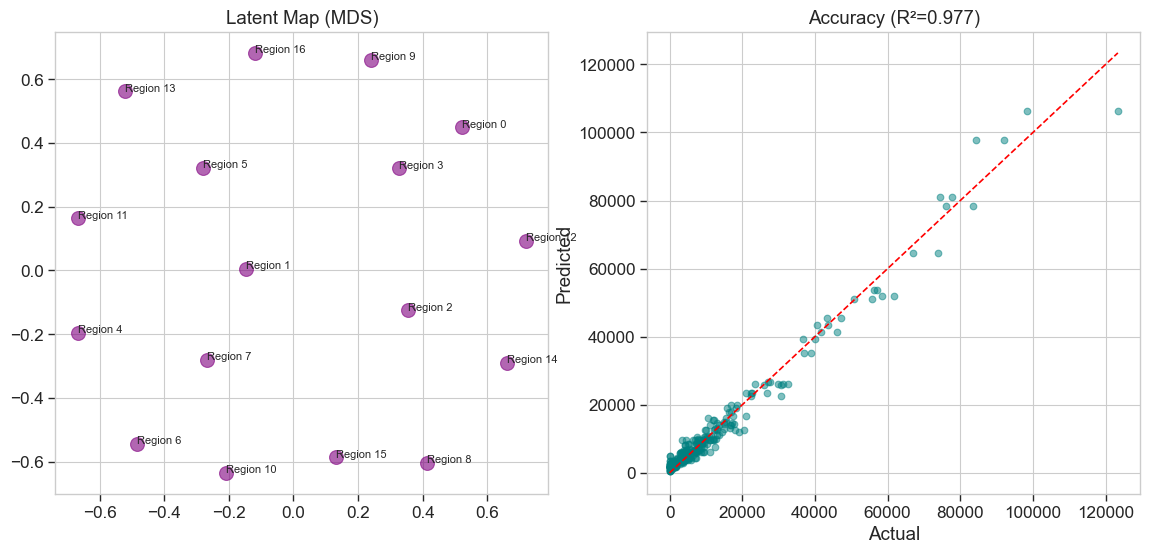

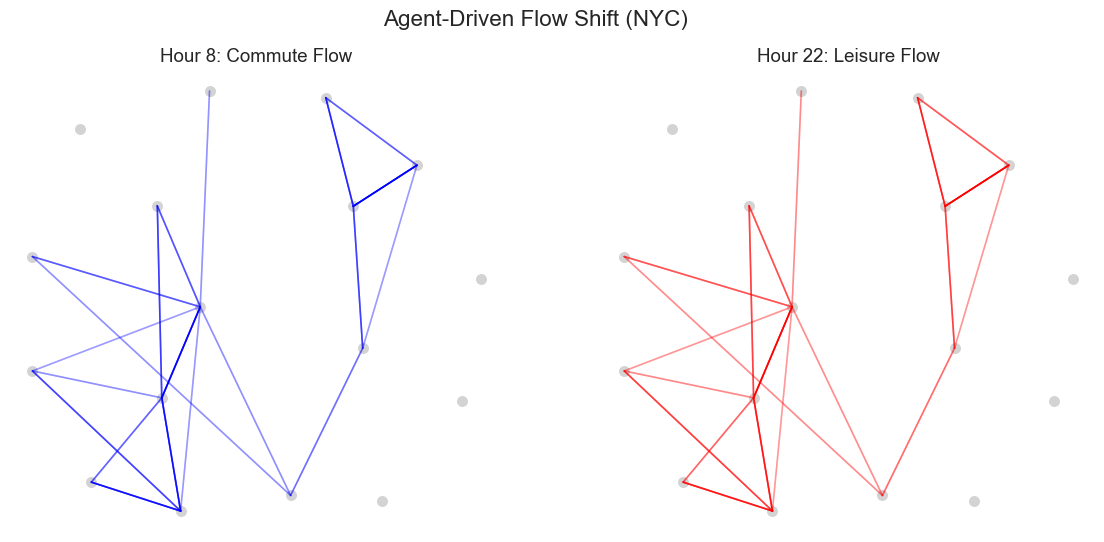


   🤖 MODEL: xai.grok-3-mini...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: NYC. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 10:44:07] {704} WARNING - Model azure_ai/grok-3-mini-high is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

{
  "0": {
    "sleep": 0.95,
    "work": 0.00,
    "leisure": 0.02,
    "home": 0.03
  },
  "1": {
    "sleep": 0.95,
    "work": 0.00,
    "leisure": 0.02,
    "home": 0.03
  },
  "2": {
    "sleep": 0.95,
    "work": 0.00,
    "leisure": 0.02,
    "home": 0.03
  },
  "3": {
    "sleep": 0.95,
    "work": 

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 10:44:22] {704} WARNING - Model azure_ai/grok-3-mini-high is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{
  "reasoning": "At 6 AM on a weekday in NYC, cultural and temporal drivers indicate a period of low activity for seniors, with a high sleep probability of 0.80 suggesting most are at home. Urban routines in NYC emphasize early morning as a time for rest and preparation rather than commuting or leisure, especially for seniors who are less likely to engage in work-related travel or recreational activities at this hour.",
  "forces": {
    "commute": 0.10,
    "leisure": 0.05,
    "home": 0.85
  }
}

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (c2692dc7-7eda-4fe0-b471-0f0b79d53220): Maximum number of consecutive auto-replies reached
      💭 Logic: At 6 AM on a weekday in

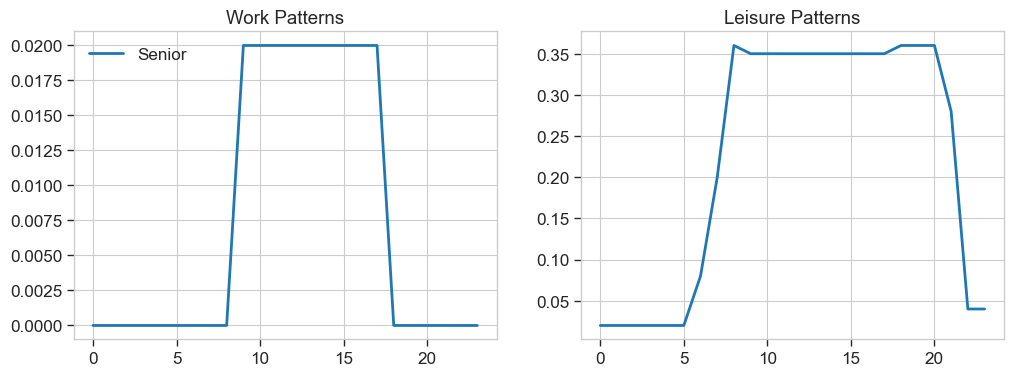

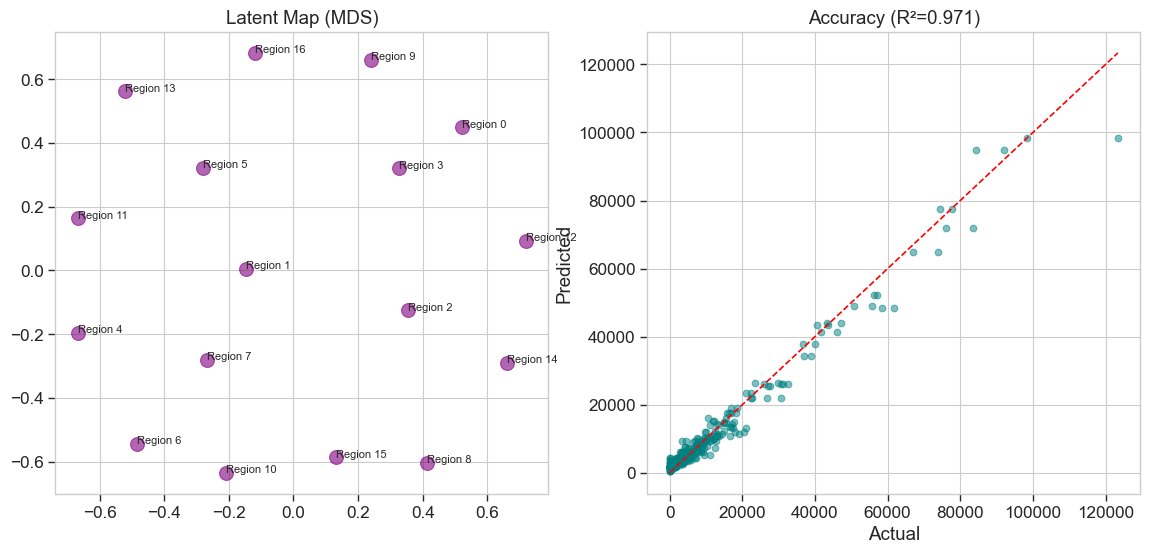

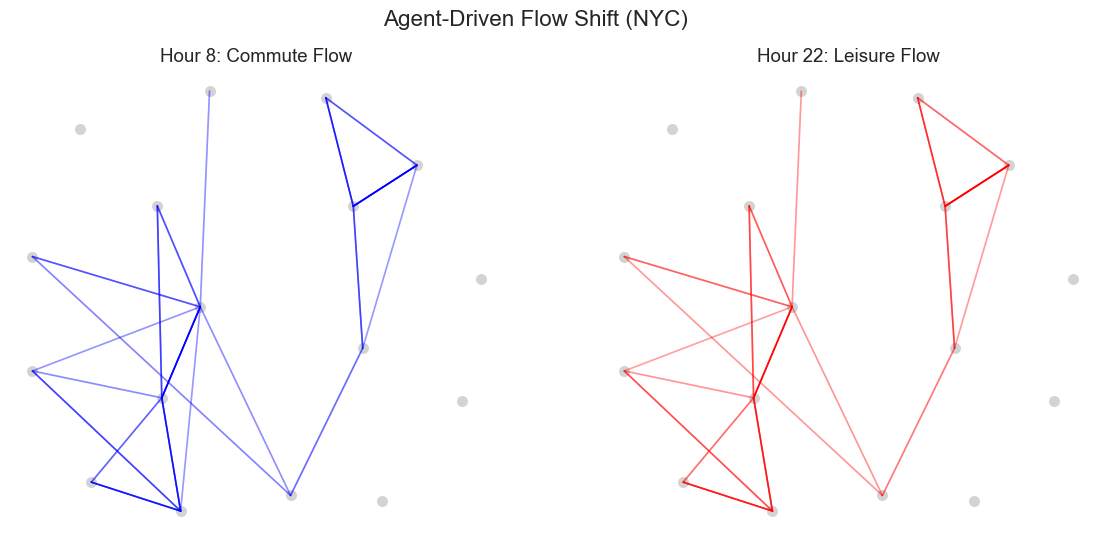


🏙️  STARTING BENCHMARK: Las Vegas

📥 [DEMOGRAPHER] Fetching Real ACS Data for Las Vegas...
   ✅ Mapped 17 zones to cohorts using Real Census Data.

   🤖 MODEL: openai.gpt-5-mini...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: Las Vegas. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
Sociologist (to user):

{"0":{"sleep":0.95,"work":0.01,"leisure":0.02,"home":0.02},"1":{"sleep":0.95,"work":0.005,"leisure":0.02,"home":0.025},"2":{"sleep":0.96,"work":0.003,"leisure":0.02,"home":0.017},"3":{"sleep":0.96,"work":0.002,"leisure":0.02,"home":0.018},"4":{"sleep":0.94,"work":0.005,"leisure":0.03,"home":0.025},"5":{"sleep":0.85,"work":0.01,"leisure":0.06,"home":0.08},"6":{"sleep":0.6,"work":0.01,"leisu

/Users/yashwanthvarma/Documents/Cornell/GenUrban/Utl.py:74: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid
/Users/yashwanthvarma/Documents/Cornell/GenUrban/Utl.py:75: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['lon'] = gdf.centroid.x
/Users/yashwanthvarma/Documents/Cornell/GenUrban/Utl.py:76: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['lat'] = gdf.centroid.y


   ✅ Spatially Joined buildings into 0 zones.
   🗺️ [TOPOLOGY] Learning Functional Map (MDS)...
   🧠 [PLANNER] Reasoning for Las Vegas @ 6:00...
user (to Planner):


        City: Las Vegas, Weekday, Hour 6.
        State: Senior: sleep (0.60).
        Task: 
        1. Analyze cultural/temporal drivers.
        2. Output 3 'Mobility Forces' (0.0-1.0).
        Output JSON: {"reasoning": "...", "forces": {"commute": <float>, "leisure": <float>, "home": <float>}}
        

--------------------------------------------------------------------------------


/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Planner (to user):

{"reasoning":"Weekday, 6:00 in Las Vegas is early-morning: core temporal drivers are the start of shift-based work (hospitality/casinos) and the cooler hours that favor outdoor exercise; cultural drivers include a large tourism/hospitality workforce that creates nonstandard commute patterns and a notable retiree population with morning routines. The provided Senior: sleep (0.60) baseline suggests a majority of seniors are still at home and many are still asleep, lowering commute likelihood. Early-morning leisure (walking, senior exercise classes, starting later errands) is present but limited at this hour. Transit options are relatively car-centric and some hospitality workers are already mobile, but that impacts overall city mobility more than senior mobility. Taken together: home/remaining at residence is the dominant force, leisure activity is modest due to the early hour, and commute (for seniors) is low.","forces":{"commute":0.10,"leisure":0.20,"home":0.75}}

-

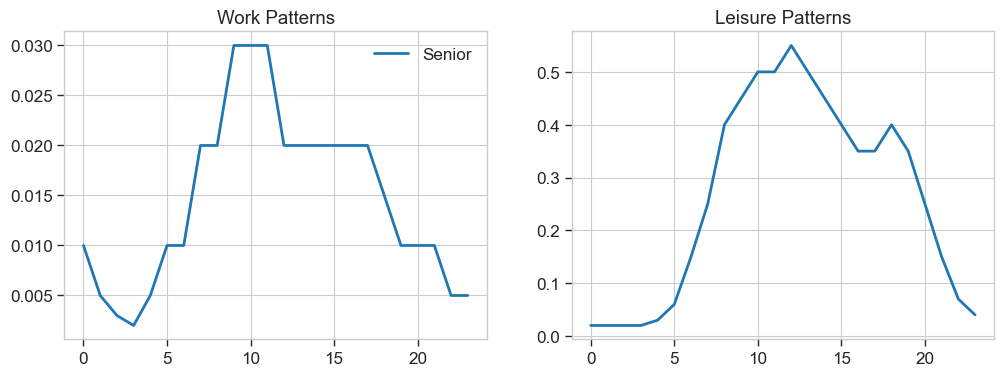

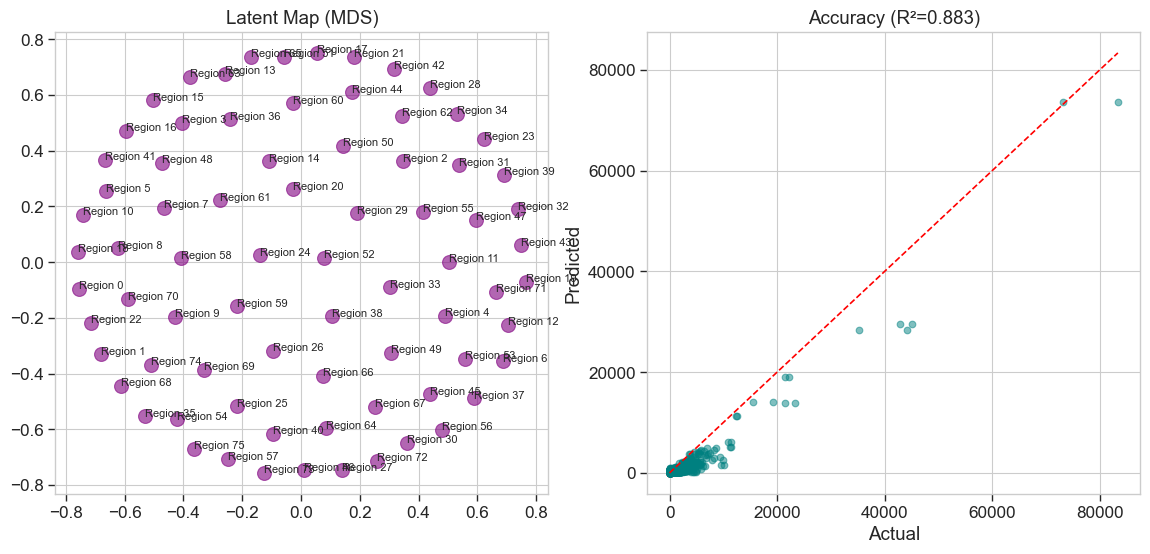

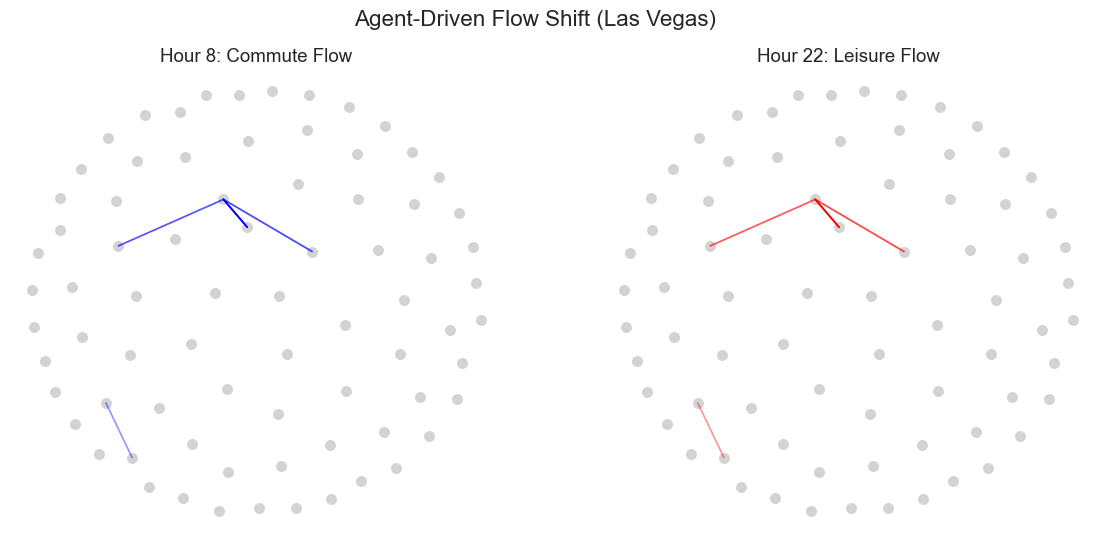


   🤖 MODEL: meta.llama-4-maverick-17b-instruct...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: Las Vegas. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 10:48:56] {704} WARNING - Model us.meta.llama4-maverick-17b-instruct-v1:0 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

```json
{
  "0": {"sleep": 0.95, "work": 0.01, "leisure": 0.03, "home": 0.98},
  "1": {"sleep": 0.96, "work": 0.01, "leisure": 0.02, "home": 0.99},
  "2": {"sleep": 0.97, "work": 0.01, "leisure": 0.01, "home": 0.99},
  "3": {"sleep": 0.98, "work": 0.01, "leisure": 0.0

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 10:49:08] {704} WARNING - Model us.meta.llama4-maverick-17b-instruct-v1:0 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

To analyze the given scenario and output the required JSON, let's break down the information and the tasks step by step.

1. **City: Las Vegas, Weekday, Hour 6.**
   - Las Vegas is known for its vibrant entertainment and tourism industry, but the specifics of the city are less relevant at 6 AM on a weekday since most leisure activities haven't started yet.
   - It's a weekday, which typically implies a routine of work or school for many people.
   - Hour 6 (6 AM) is early morning, a time when most people are at home.

2. **State: Senior: home (0.80).**
   - The individual is a senior, implying they are likely retired or semi-retired.
   - The probability of being at home is 0.80, indicating a high likelihood of the 

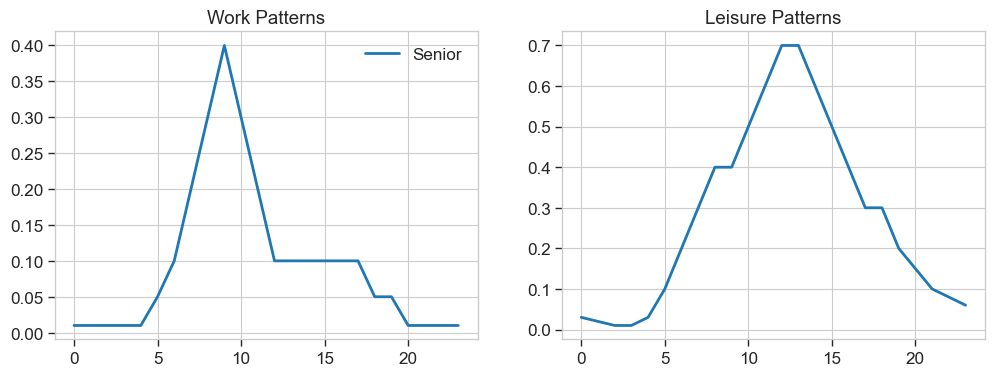

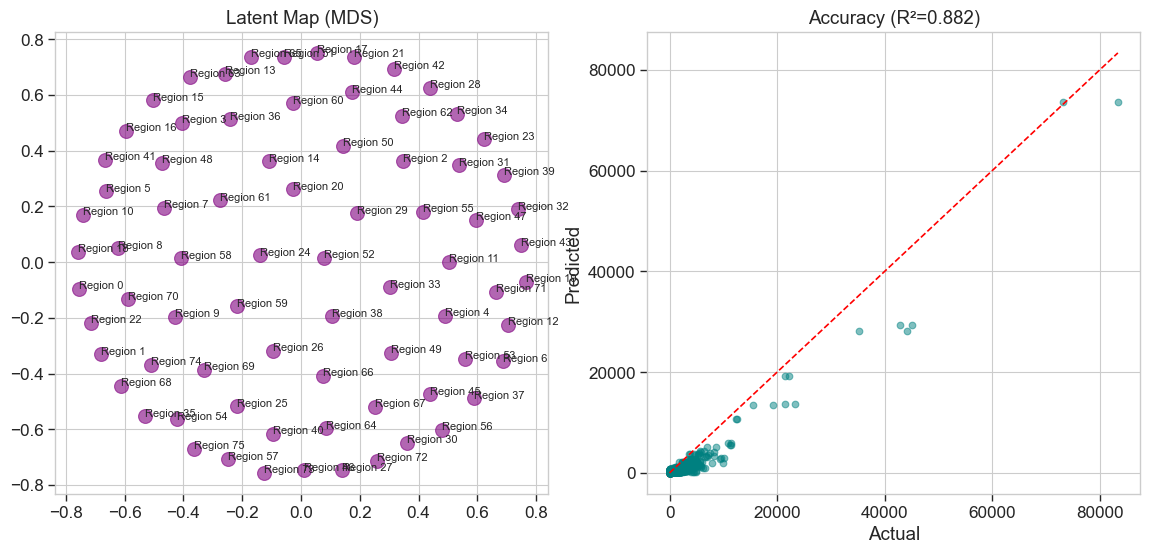

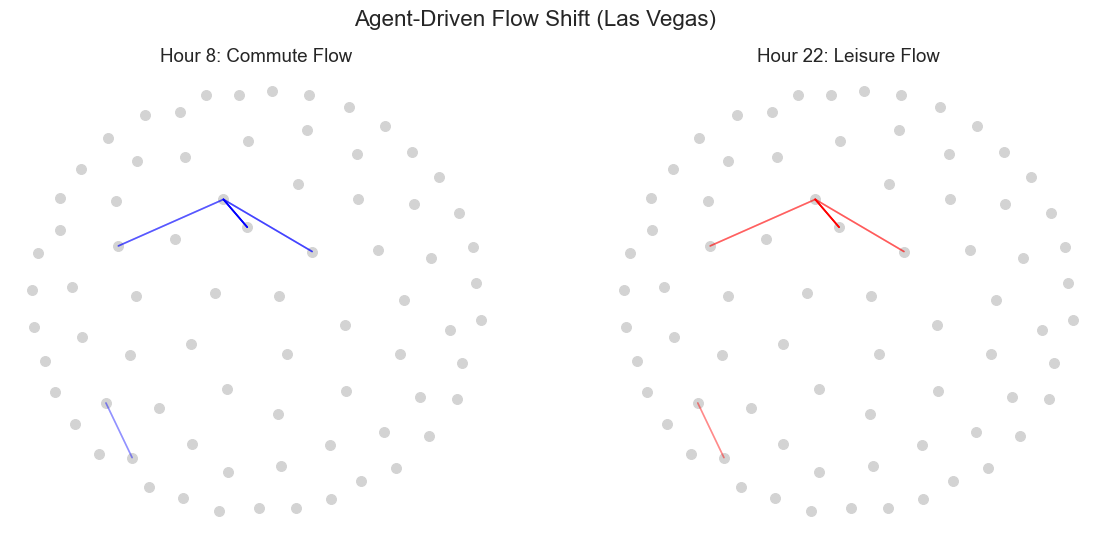


   🤖 MODEL: google.gemini-2.5-flash...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: Las Vegas. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 10:49:53] {704} WARNING - Model gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

```json
{
  "0": {
    "sleep": 0.85,
    "work": 0.0,
    "leisure": 0.05,
    "home": 0.1
  },
  "1": {
    "sleep": 0.9,
    "work": 0.0,
    "leisure": 0.02,
    "home": 0.08
  },
  "2": {
    "sleep": 0.95,
    "work": 0.0,
    "leisure": 0.01,
    "home": 0.04
  },
  "3": {
    "sleep": 0.95,
    

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 10:50:10] {704} WARNING - Model gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

```json
{
  "reasoning": "At 6 AM on a weekday in Las Vegas, the primary drivers are the start of the workday and people transitioning from sleep to their daily routines. Many in the hospitality and service industries begin early shifts, leading to significant early morning commute activity. While not peak rush hour, it's a critical 'wake-up and get moving' period. A large portion of the population is still at home, either sleeping (as indicated by 50% of seniors still sleeping) or preparing for work/school. Leisure activities are generally very low at this hour, with most entertainment venues either closed or just opening, and tourist activity only just beginning to stir. The 'senior: sleep' state directly reinforces a high 'home' score fo

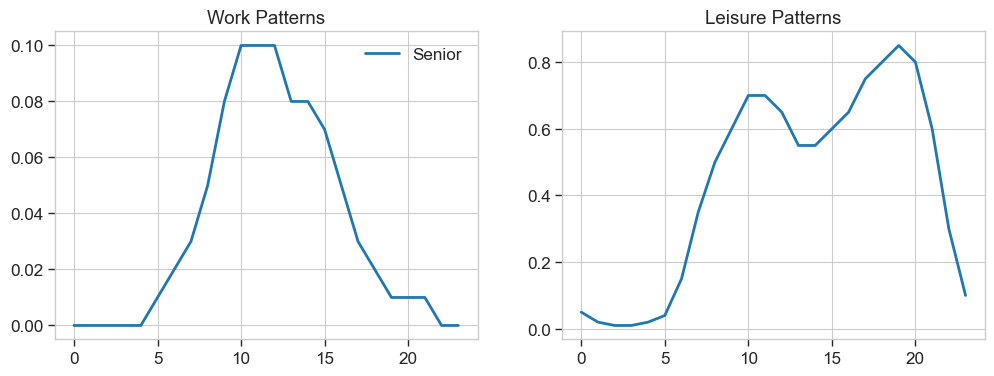

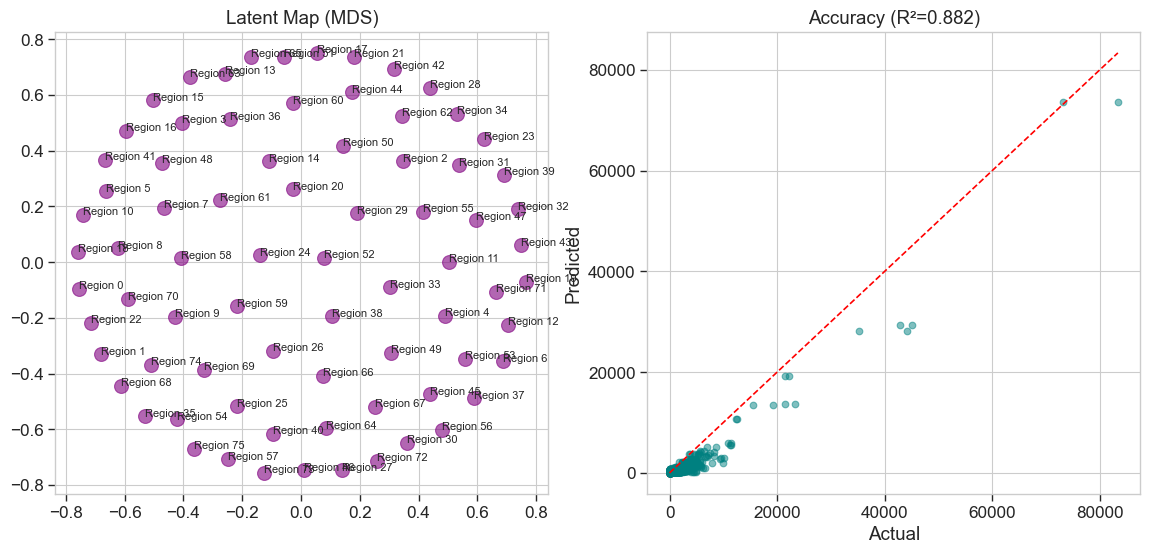

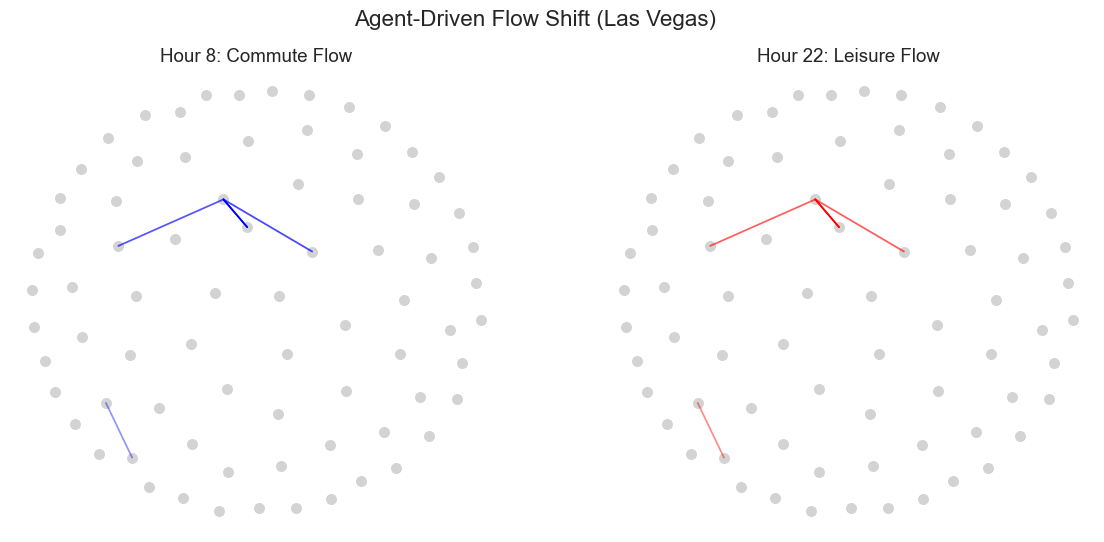


   🤖 MODEL: xai.grok-3-mini...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: Las Vegas. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 10:52:00] {704} WARNING - Model azure_ai/grok-3-mini-high is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

{
  "0": {
    "sleep": 0.95,
    "work": 0.00,
    "leisure": 0.03,
    "home": 0.02
  },
  "1": {
    "sleep": 0.95,
    "work": 0.00,
    "leisure": 0.03,
    "home": 0.02
  },
  "2": {
    "sleep": 0.95,
    "work": 0.00,
    "leisure": 0.03,
    "home": 0.02
  },
  "3": {
    "sleep": 0.95,
    "w

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 10:52:22] {704} WARNING - Model azure_ai/grok-3-mini-high is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{
  "reasoning": "In Las Vegas on a weekday at 6 AM, temporal drivers indicate a low-activity period as the city transitions from nightlife to daytime routines, with most residents likely at home or just waking up. Culturally, Las Vegas is known for entertainment and 24/7 vibrancy, but this diminishes in the early morning, especially for seniors who may prioritize rest. Given the senior's state with a 70% probability of being asleep, mobility is significantly reduced, minimizing drives for commuting or leisure activities while strengthening the pull towards staying home.",
  "forces": {
    "commute": 0.10,
    "leisure": 0.05,
    "home": 0.85
  }
}

--------------------------------------------------------------------------------


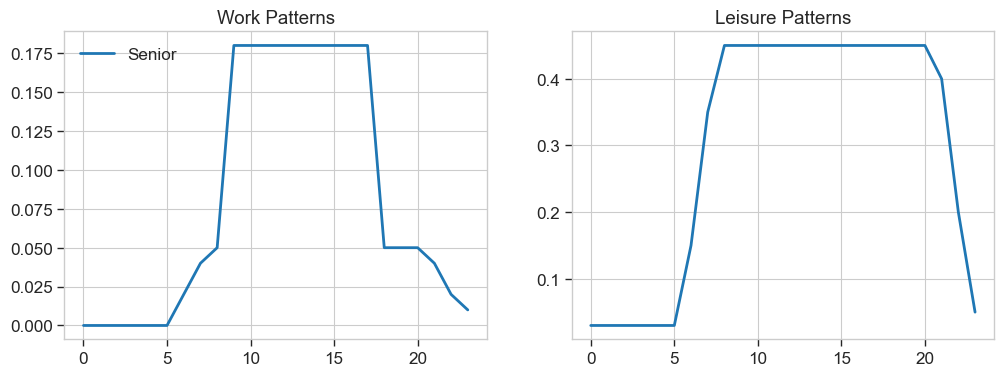

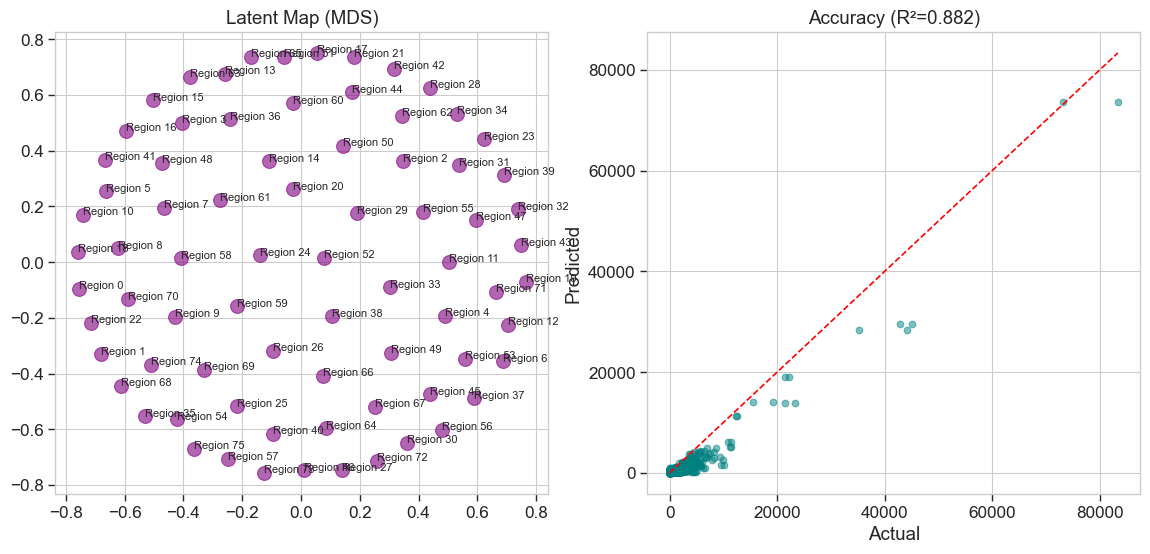

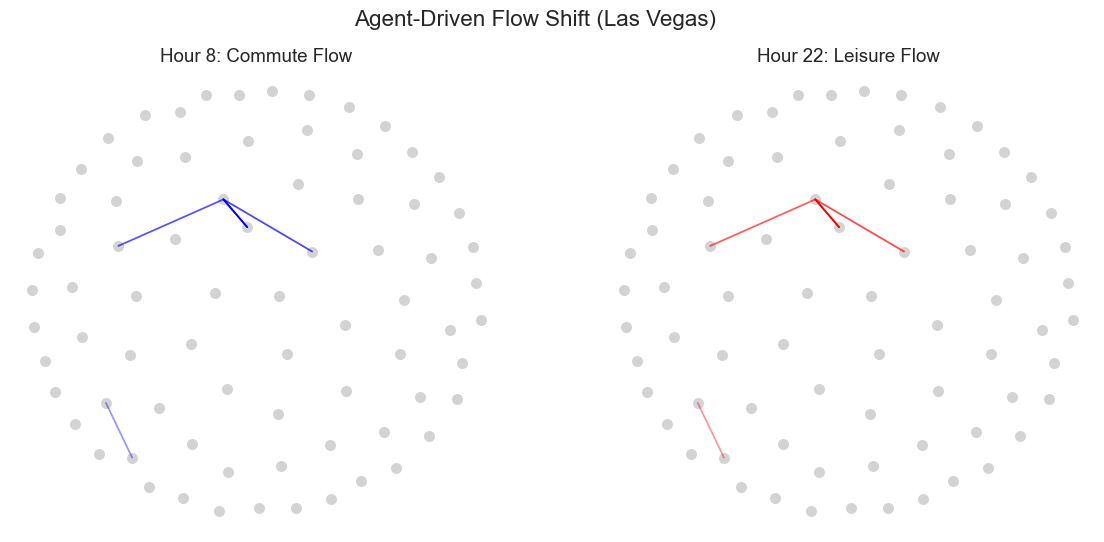


🏙️  STARTING BENCHMARK: San Francisco

📥 [DEMOGRAPHER] Fetching Real ACS Data for San Francisco...
   ✅ Mapped 17 zones to cohorts using Real Census Data.

   🤖 MODEL: openai.gpt-5-mini...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: San Francisco. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
Sociologist (to user):

{
  "0": {"sleep": 0.95, "work": 0.00, "leisure": 0.02, "home": 0.03},
  "1": {"sleep": 0.96, "work": 0.00, "leisure": 0.01, "home": 0.03},
  "2": {"sleep": 0.97, "work": 0.00, "leisure": 0.01, "home": 0.02},
  "3": {"sleep": 0.97, "work": 0.00, "leisure": 0.01, "home": 0.02},
  "4": {"sleep": 0.96, "work": 0.00, "leisure": 0.02, "home": 0.02},
  "5": {"sleep": 0.90, "work": 0.

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Planner (to user):

{
  "reasoning": "6:00 AM on a weekday in San Francisco is the early ramp of the morning commute and a strong time for solo outdoor activity (walking, jogging, transit/bike prep), but the given senior state indicates a high probability of still being asleep (0.70). Culturally, SF has active morning street life and reliable early transit, which raises overall city commute/leisure activity relative to rural areas, yet seniors are less likely to participate in peak work commutes and more likely to remain at home or do short, local leisure (morning walks, errands). Combining the 70% sleep baseline with typical early-morning senior routines (some wake for light leisure, low probability of commuting) yields a dominant home force, modest leisure, and minimal commute tendency.",
  "forces": {
    "commute": 0.05,
    "leisure": 0.20,
    "home": 0.80
  }
}

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (dd556ab8-9

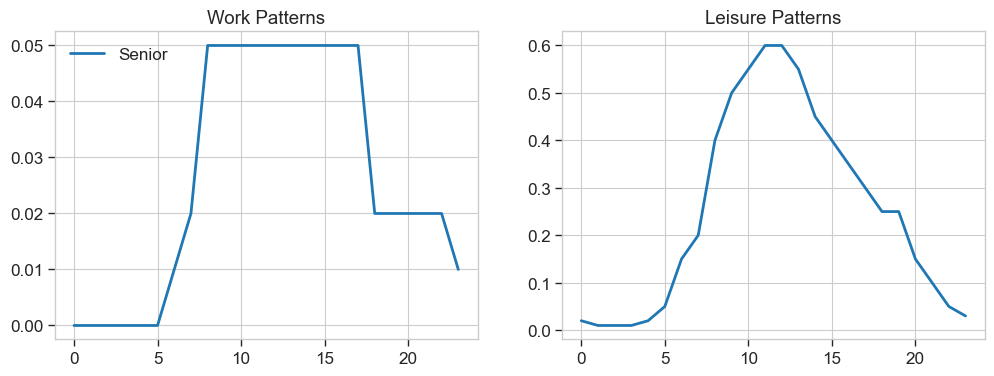

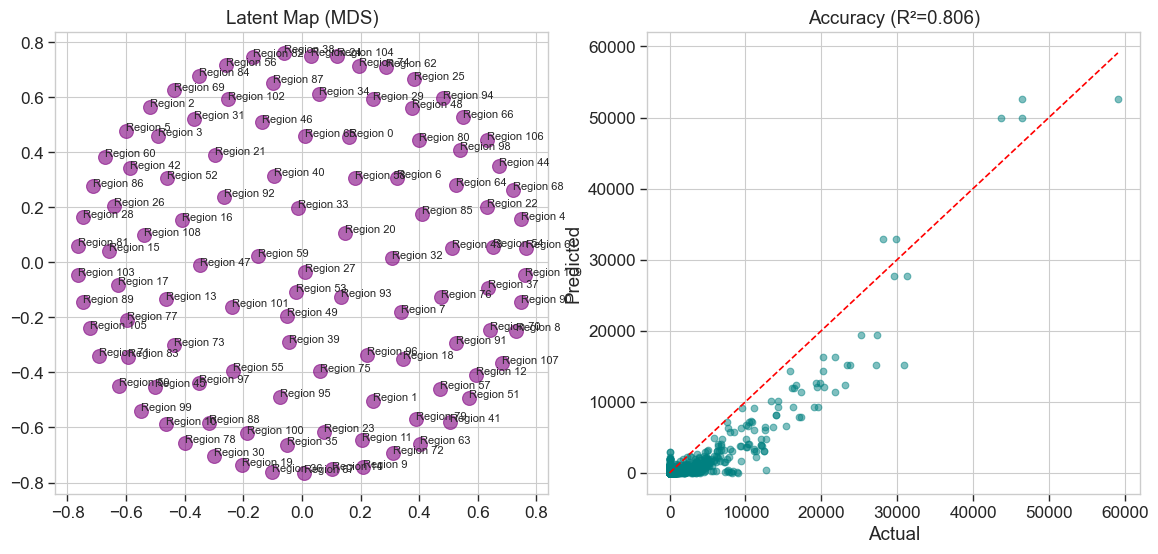

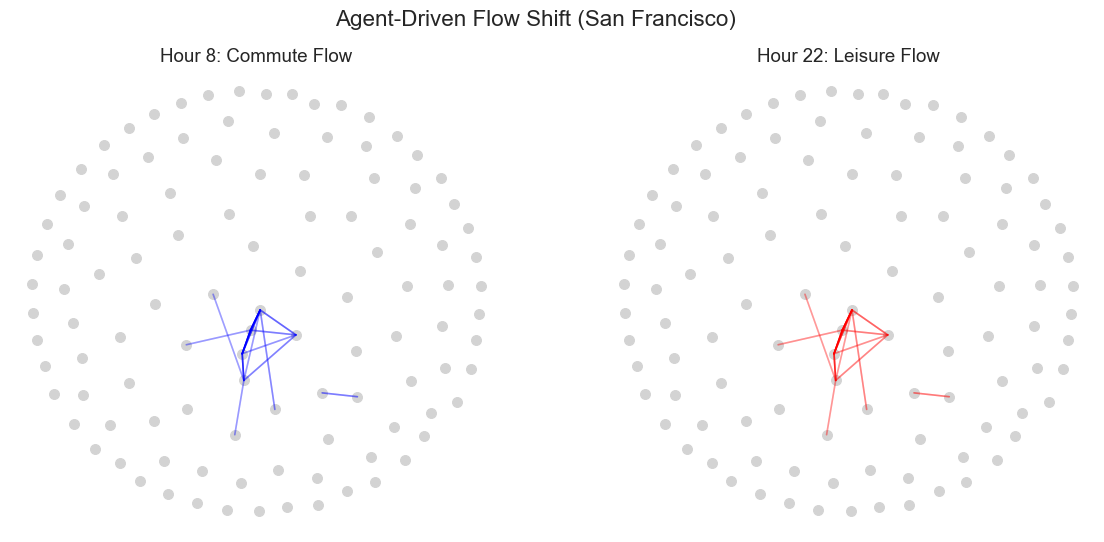


   🤖 MODEL: meta.llama-4-maverick-17b-instruct...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: San Francisco. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 10:56:12] {704} WARNING - Model us.meta.llama4-maverick-17b-instruct-v1:0 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

```json
{
  "0": {"sleep": 0.95, "work": 0.01, "leisure": 0.03, "home": 0.98},
  "1": {"sleep": 0.96, "work": 0.01, "leisure": 0.02, "home": 0.99},
  "2": {"sleep": 0.97, "work": 0.00, "leisure": 0.02, "home": 0.99},
  "3": {"sleep": 0.98, "work": 0.00, "leisure":

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 10:56:20] {704} WARNING - Model us.meta.llama4-maverick-17b-instruct-v1:0 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

To tackle this task, let's break it down into steps and analyze the given information.

1. **Understanding the Context**: We're given a scenario set in San Francisco on a weekday at hour 6 (early morning). The individual in question is a senior who is likely to be at home, given the probability of 0.80.

2. **Analyzing Cultural/Temporal Drivers**:
   - **Location (San Francisco)**: Known for its dense population and urban lifestyle, with a mix of tech industry professionals and a significant senior population.
   - **Weekday**: Indicates a day when most people are likely to be following a routine that includes work or other regular activities.
   - **Hour 6**: Early morning. For most people, this is a time for wakin

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 10:57:26] {704} WARNING - Model gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

```json
{
  "reasoning": "At 6 AM on a weekday in San Francisco, the dominant driver for seniors is likely remaining at home, aligning with the provided 'home: 0.90' state. This early hour is typically before peak activity for most demographic groups, and particularly for seniors who often have more flexible schedules and reduced work commitments. Cultural drivers include the tendency for seniors to prioritize sleep or engage in quiet home routines during early mornings. Temporal drivers strongly point to home-based activities as most businesses and leisure venues are not yet open, and traditional work commutes are rare for this demographic. While some early morning appointments (medical, volunteer) or very early leisure (e.g., a walk) migh

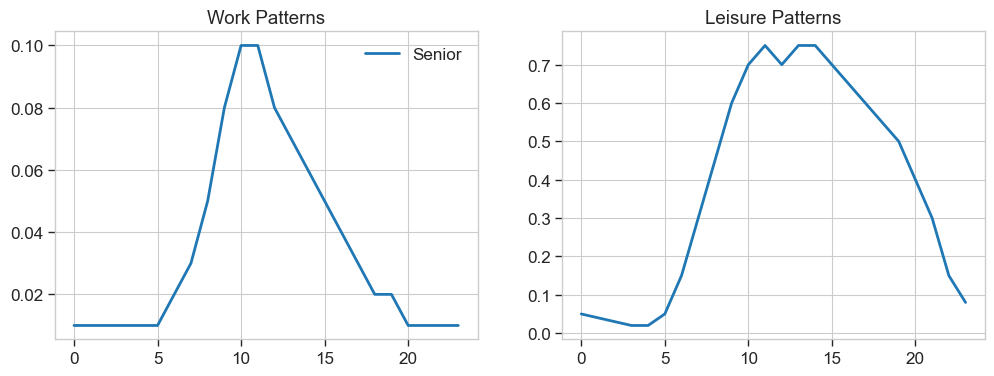

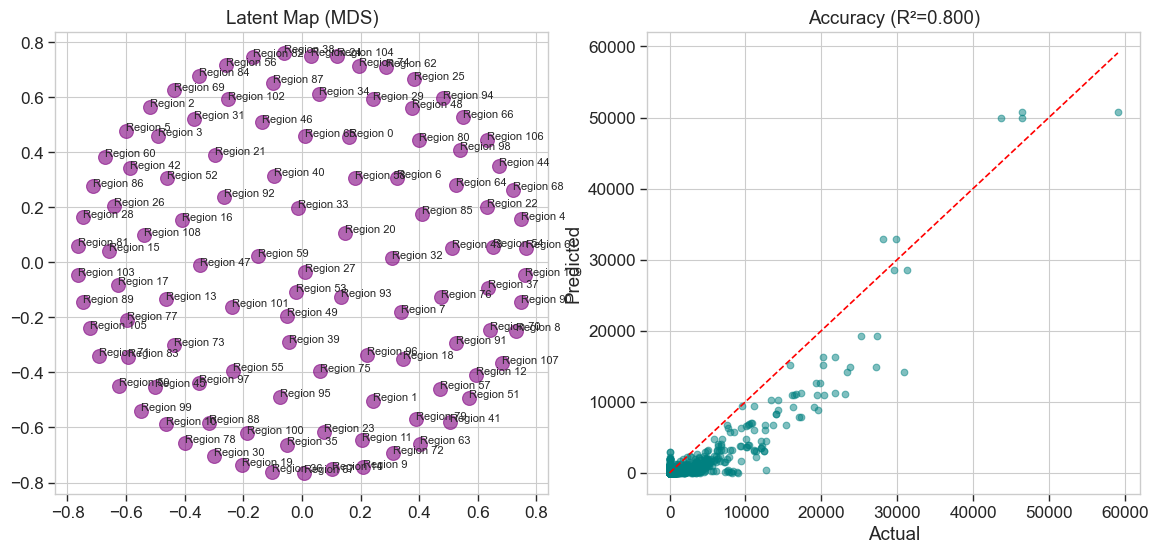

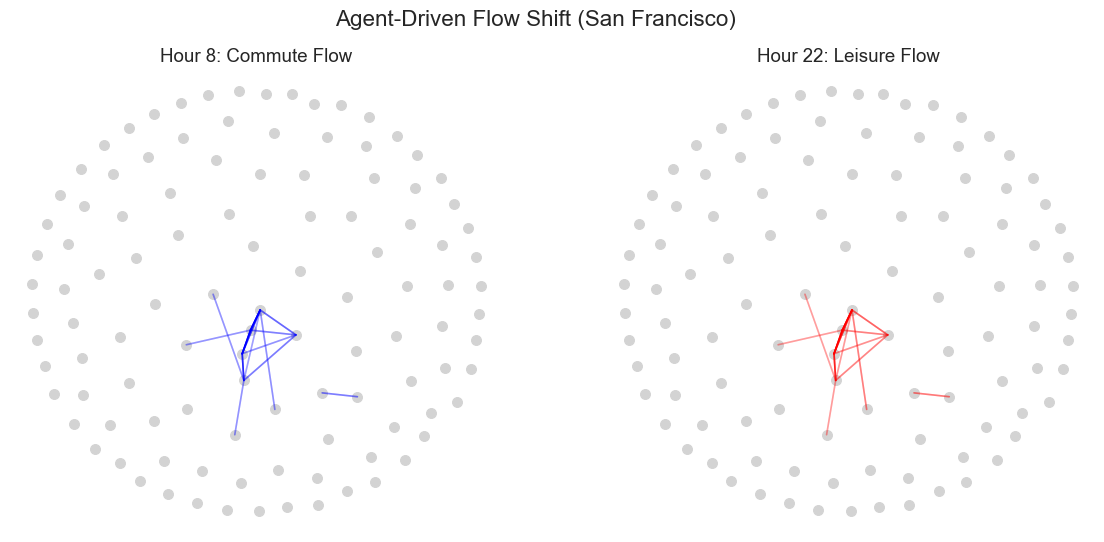


   🤖 MODEL: xai.grok-3-mini...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: San Francisco. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 10:59:20] {704} WARNING - Model azure_ai/grok-3-mini-high is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

{
  "0": {"sleep": 0.95, "work": 0.00, "leisure": 0.02, "home": 0.04},
  "1": {"sleep": 0.95, "work": 0.00, "leisure": 0.02, "home": 0.04},
  "2": {"sleep": 0.95, "work": 0.00, "leisure": 0.02, "home": 0.04},
  "3": {"sleep": 0.95, "work": 0.00, "leisure": 0.02, "home": 0.04},
  "4": {"sleep": 0.95

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 10:59:36] {704} WARNING - Model azure_ai/grok-3-mini-high is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{
  "reasoning": "In San Francisco, cultural drivers include a fast-paced urban lifestyle, but for seniors, routines often prioritize rest and home-based activities. Temporally, at 6 AM on a weekday, this is early morning when commuting has not yet peaked, and most people, especially seniors, are likely at home or asleep. With a 0.70 sleep probability, mobility is significantly reduced, emphasizing home-centric forces. Commute force is low due to the early hour and potential retirement status. Leisure force is minimal as recreational activities are uncommon at this time. Home force is high, reflecting the sleep state and typical morning routines.",
  "forces": {
    "commute": 0.10,
    "leisure": 0.05,
    "home": 0.85
  }
}

----

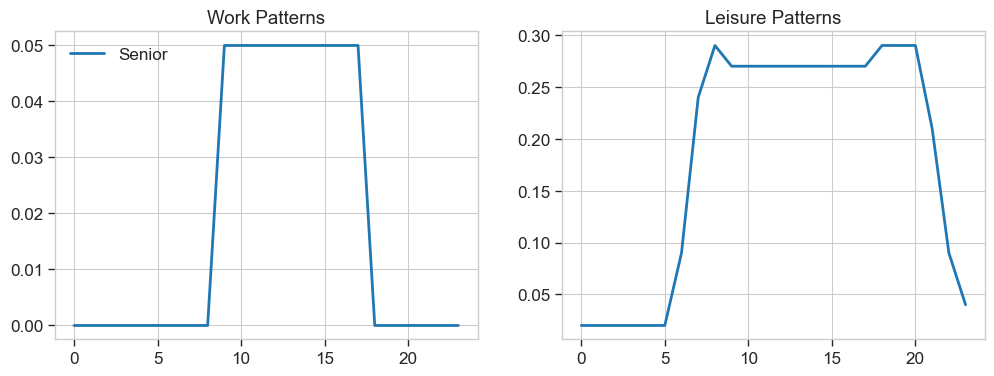

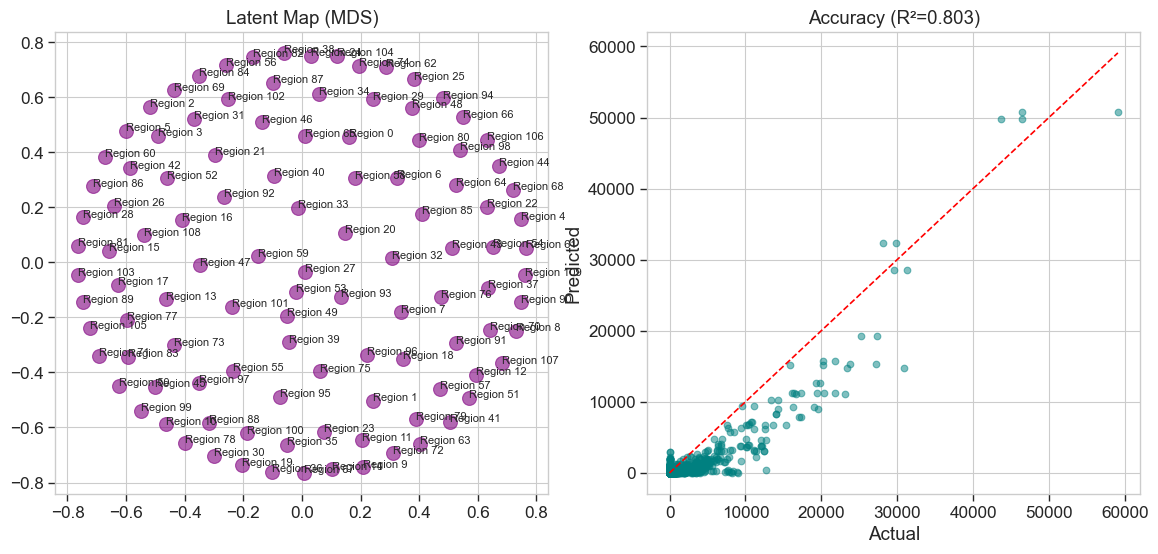

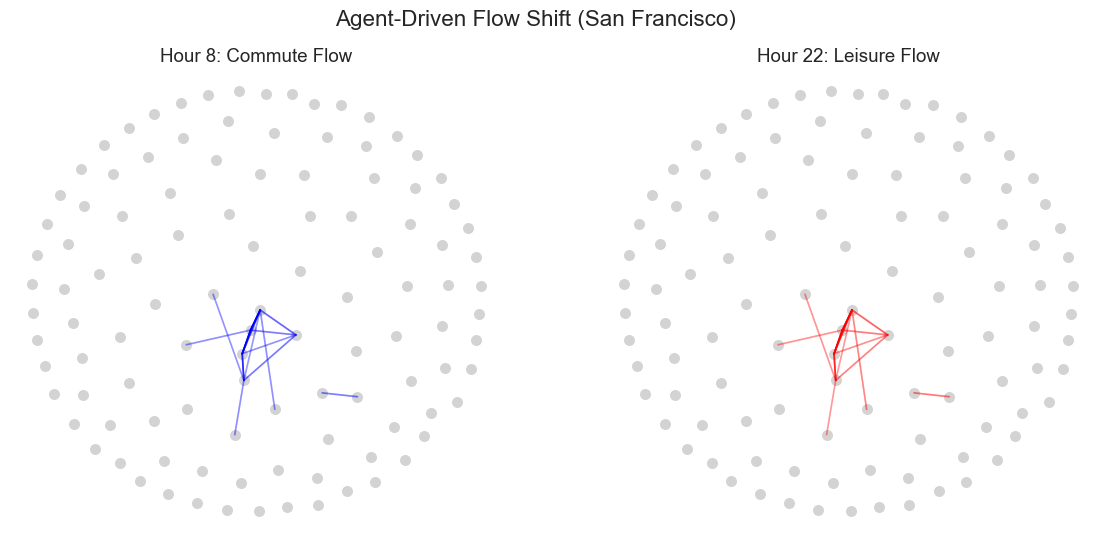


🏙️  STARTING BENCHMARK: Minneapolis

📥 [DEMOGRAPHER] Fetching Real ACS Data for Minneapolis...
   ✅ Mapped 17 zones to cohorts using Real Census Data.

   🤖 MODEL: openai.gpt-5-mini...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: Minneapolis. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
Sociologist (to user):

{"0":{"sleep":0.92,"work":0.0,"leisure":0.03,"home":0.05},"1":{"sleep":0.93,"work":0.0,"leisure":0.03,"home":0.04},"2":{"sleep":0.94,"work":0.0,"leisure":0.02,"home":0.04},"3":{"sleep":0.95,"work":0.0,"leisure":0.01,"home":0.04},"4":{"sleep":0.94,"work":0.0,"leisure":0.01,"home":0.05},"5":{"sleep":0.90,"work":0.0,"leisure":0.03,"home":0.07},"6":{"sleep":0.70,"work":0.0,"leisure":0.10

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Planner (to user):

{
  "reasoning": "At 06:00 on a weekday in Minneapolis most seniors remain at home: the provided senior sleep probability (0.70) implies a strong baseline of in-home, low-mobility behavior. Temporal drivers: 6 AM is pre-peak for general commute flows (rush hour typically ramps up after 6), so only a minority of seniors are leaving early for work, appointments, or errands. Cultural/drivers specific to Minneapolis: seasonal weather (cold, ice, snow) and shorter winter daylight suppress early-morning outdoor activity for older adults; conversely, a subset attends early medical appointments, shift work, or indoor exercise programs at community centers. Institutional factors (assisted living, morning care routines) concentrate seniors at home or in-site. Taken together this produces high residual home presence, low leisure activity at this hour, and only a small but non-zero early-commute component.",
  "forces": {
    "commute": 0.18,
    "leisure": 0.08,
    "home": 0.

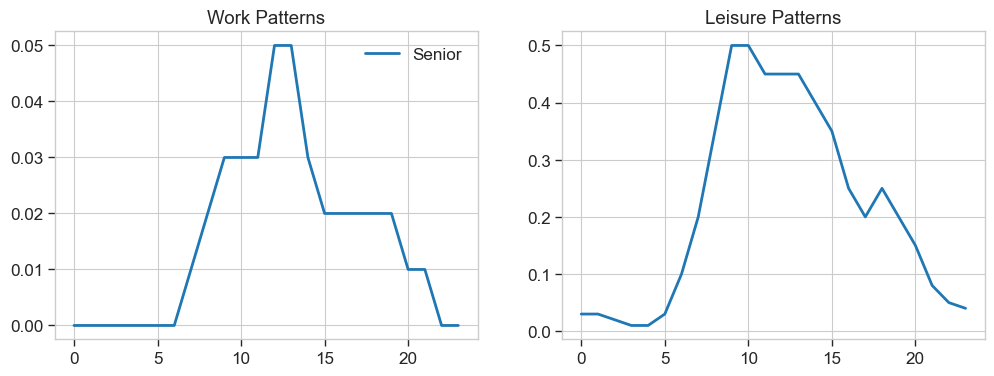

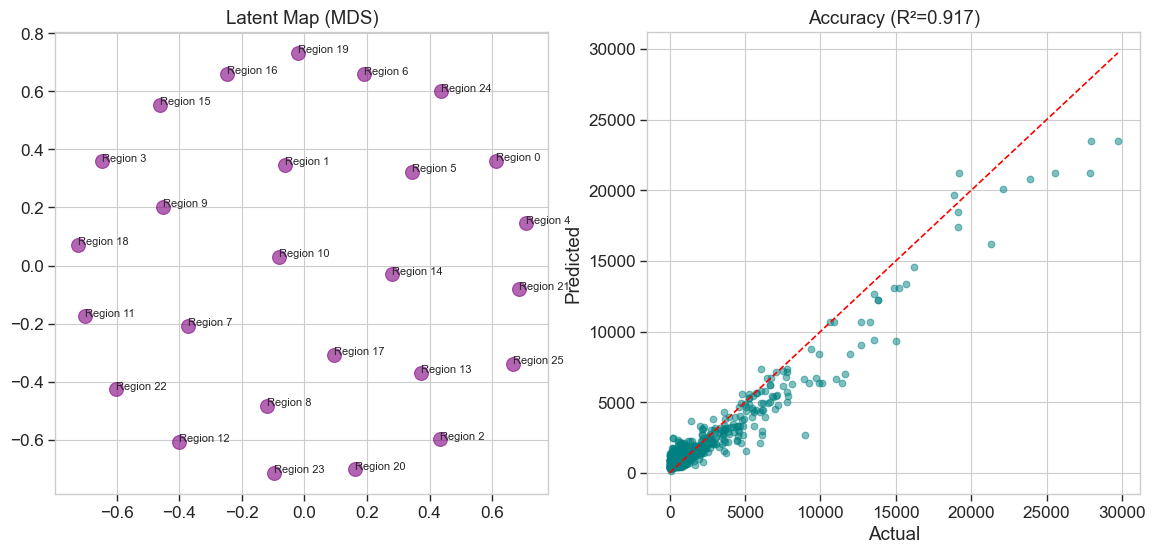

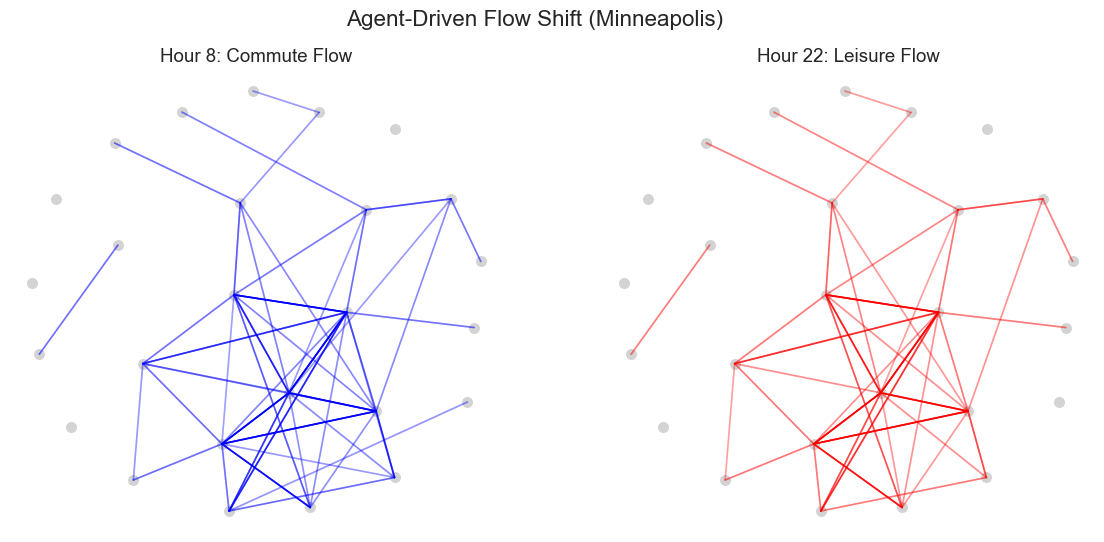


   🤖 MODEL: meta.llama-4-maverick-17b-instruct...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: Minneapolis. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 11:04:09] {704} WARNING - Model us.meta.llama4-maverick-17b-instruct-v1:0 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

```json
{
  "0": {"sleep": 0.95, "work": 0.01, "leisure": 0.03, "home": 0.98},
  "1": {"sleep": 0.96, "work": 0.01, "leisure": 0.02, "home": 0.99},
  "2": {"sleep": 0.97, "work": 0.00, "leisure": 0.02, "home": 0.99},
  "3": {"sleep": 0.98, "work": 0.00, "leisure": 0

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 11:04:17] {704} WARNING - Model us.meta.llama4-maverick-17b-instruct-v1:0 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

To solve this task, let's break it down into steps and analyze the given information.

1. **Given Information**:
   - City: Minneapolis
   - Day: Weekday
   - Hour: 6
   - State: Senior, at home (with a probability or confidence of 0.90)

2. **Analyzing Cultural/Temporal Drivers**:
   - **City (Minneapolis)**: Minneapolis is known for having a relatively structured daily routine, with a significant portion of the population adhering to traditional working hours. However, being a senior, the individual might not be part of the active workforce.
   - **Weekday**: Weekdays are typically associated with work or school routines for most people. Seniors, however, might have more variable schedules, often with more time fo

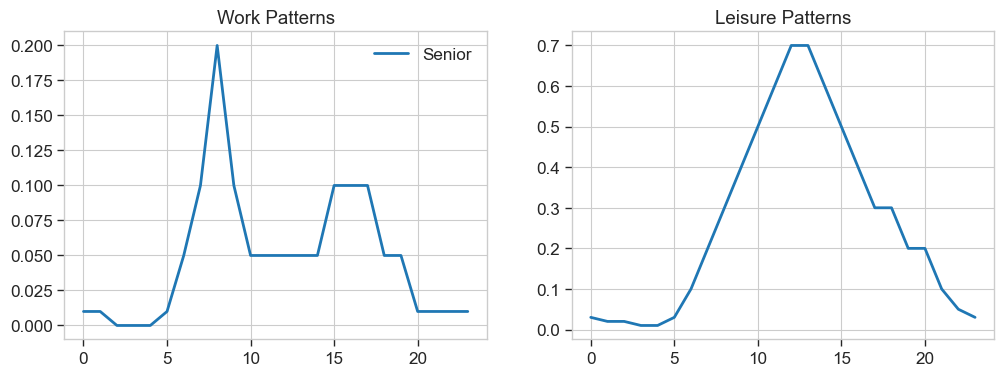

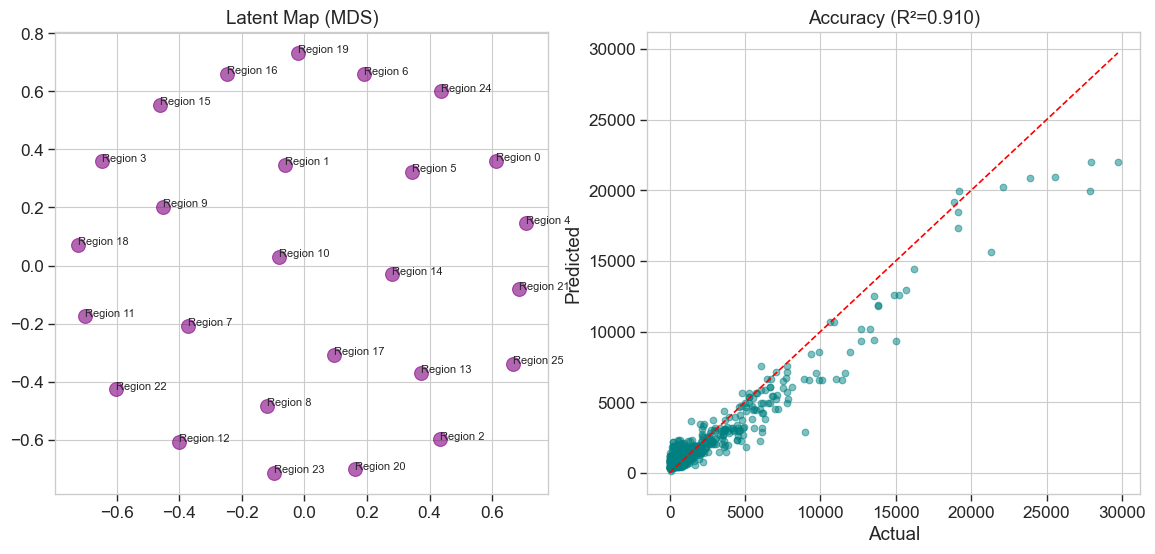

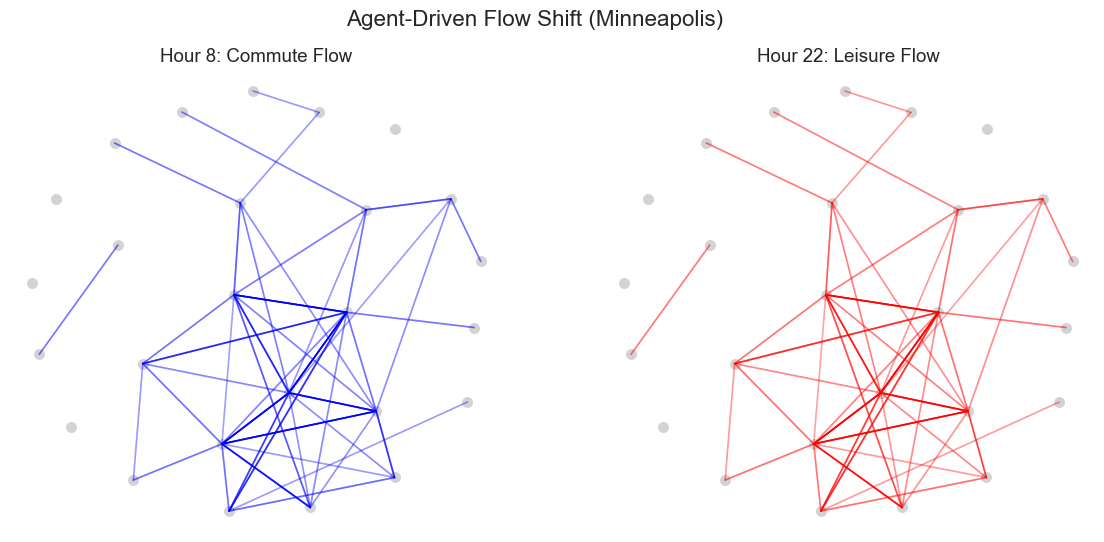


   🤖 MODEL: google.gemini-2.5-flash...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: Minneapolis. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 11:05:21] {704} WARNING - Model gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

```json
{
  "0": {
    "sleep": 0.95,
    "work": 0.01,
    "leisure": 0.03,
    "home": 0.98
  },
  "1": {
    "sleep": 0.96,
    "work": 0.005,
    "leisure": 0.02,
    "home": 0.985
  },
  "2": {
    "sleep": 0.97,
    "work": 0.005,
    "leisure": 0.01,
    "home": 0.99
  },
  "3": {
    "sleep": 

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 11:05:27] {704} WARNING - Model gemini-2.5-flash is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

```json
{
  "reasoning": "At 6 AM on a weekday in Minneapolis, the primary cultural and temporal drivers revolve around the start of the typical workday and the end of the sleep cycle. Most residents are either still asleep, just waking up, or engaged in morning preparations at home (e.g., breakfast, getting ready for work/school). While the main rush hour for commutes typically begins slightly later (7-9 AM), a segment of the workforce, particularly those with early shifts or longer commutes, will be starting their journeys. Leisure activities are extremely low at this hour, as most recreational facilities, entertainment venues, and social gathering spots are closed.",
  "forces": {
    "commute": 0.4,
    "leisure": 0.05,
    "home": 0.85

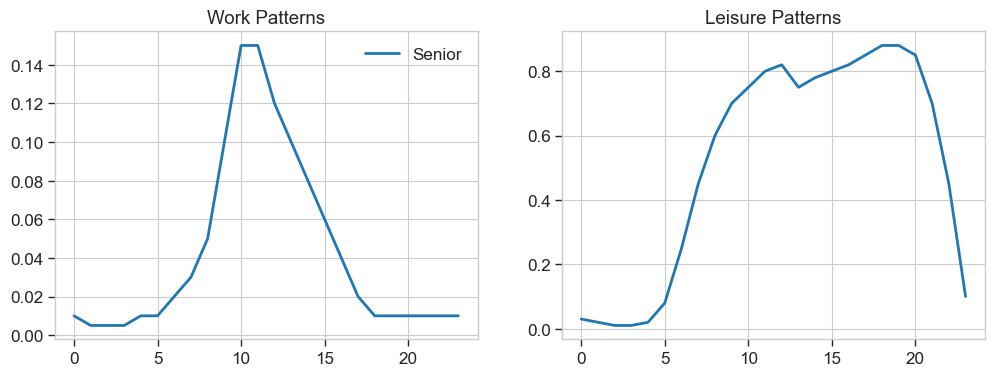

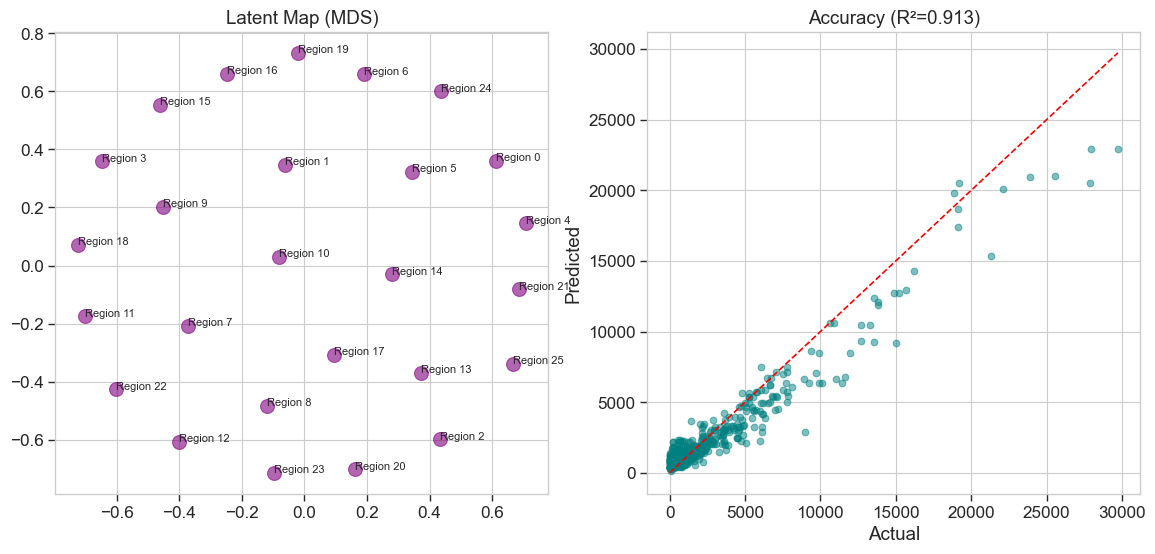

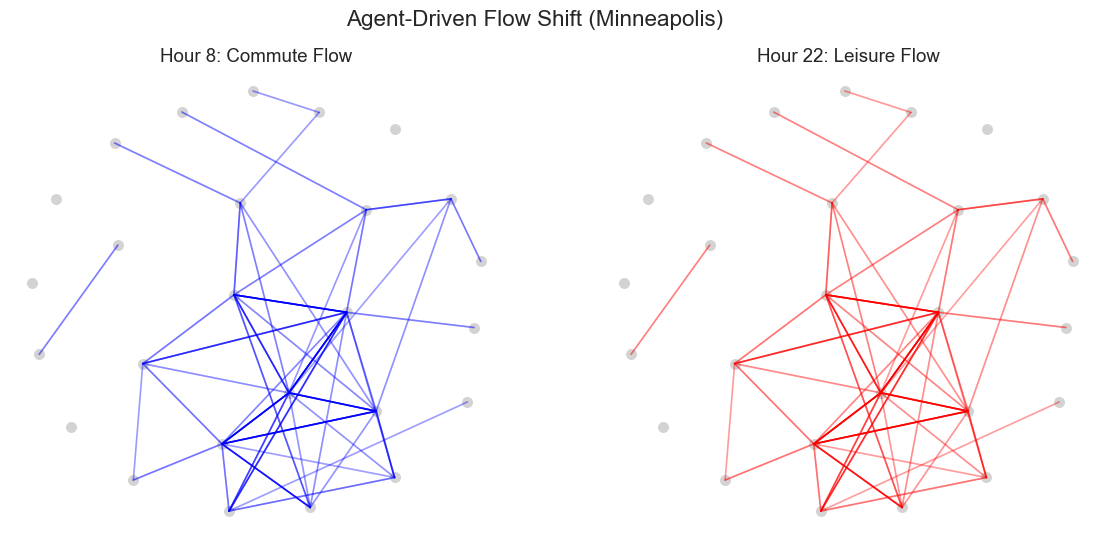


   🤖 MODEL: xai.grok-3-mini...

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: Minneapolis. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
[autogen.oai.client: 02-11 11:07:32] {704} WARNING - Model azure_ai/grok-3-mini-high is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Sociologist (to user):

{
  "0": {"sleep": 0.95, "work": 0.01, "leisure": 0.01, "home": 0.03},
  "1": {"sleep": 0.95, "work": 0.01, "leisure": 0.01, "home": 0.03},
  "2": {"sleep": 0.95, "work": 0.01, "leisure": 0.01, "home": 0.03},
  "3": {"sleep": 0.95, "work": 0.01, "leisure": 0.01, "home": 0.03},
  "4": {"sleep": 0.95, 

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


[autogen.oai.client: 02-11 11:07:45] {704} WARNING - Model azure_ai/grok-3-mini-high is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Planner (to user):

{
  "reasoning": "At 6 AM on a weekday in Minneapolis, temporal drivers indicate early morning hours when most people are waking up or preparing for the day, with low overall mobility due to routine home-based activities. Culturally, Minneapolis follows typical U.S. urban norms where weekdays see commuting peaks later in the morning, but for a senior citizen with a sleep state of 0.50 (indicating a moderate likelihood of being asleep), mobility is reduced. Seniors often have retired lifestyles, prioritizing rest over commuting or leisure at this hour. Thus, commute and leisure forces are low, while home force is high due to the likelihood of being at home or engaged in sedentary activities.",
  "forces": {
    "commute": 0.15,
    

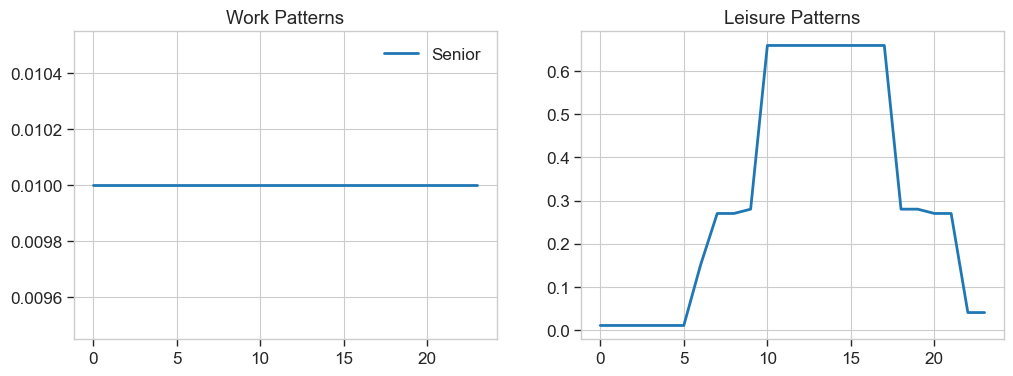

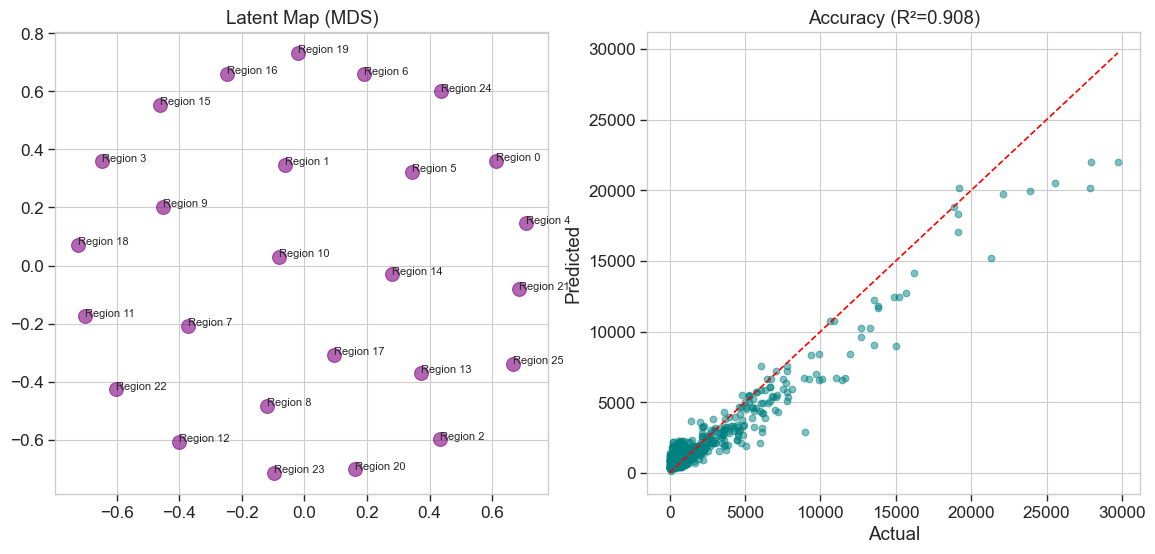

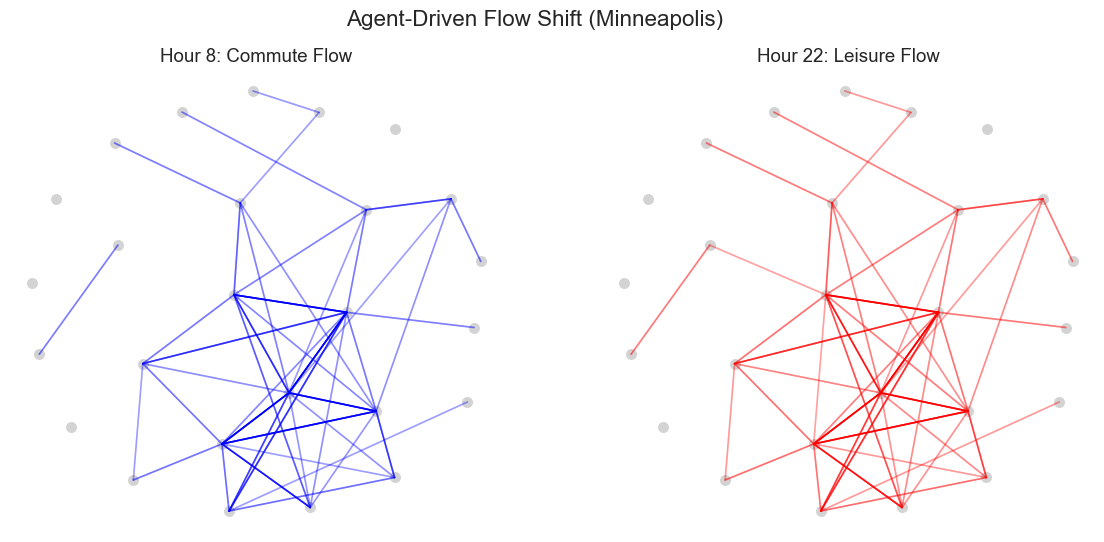


📊 FINAL INDEPENDENT MODEL COMPARISON
Model          google.gemini-2.5-flash  meta.llama-4-maverick-17b-instruct  \
City                                                                         
Las Vegas                     0.881792                            0.881752   
Minneapolis                   0.913350                            0.910475   
NYC                           0.976983                            0.966969   
San Francisco                 0.800012                            0.799608   

Model          openai.gpt-5-mini  xai.grok-3-mini  
City                                               
Las Vegas               0.882773         0.882215  
Minneapolis             0.917284         0.907714  
NYC                     0.967329         0.971301  
San Francisco           0.805780         0.802663  

🏆 BEST PERFORMING MODELS:
City
Las Vegas              openai.gpt-5-mini
Minneapolis            openai.gpt-5-mini
NYC              google.gemini-2.5-flash
San Francisco          ope

In [14]:
# ==============================================================================
# 🏁 CELL 7: MASTER EXPERIMENT LOOP
# ==============================================================================
cities_db = {
    "NYC": {
        "train": ["New-york-city-boroughs/new-york-city-boroughs.geojson Flow 6-9.csv", "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 10-13.csv", "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 14-17.csv", "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 18-21.csv"],
        "test": "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 22-25.csv",
        "state": "36", "county": "061",
        "bbox": (-74.02, 40.70, -73.93, 40.80), 
        "geojson": "CityHex20Exp/new-york-city-boroughs.geojson"
    },
    "Las Vegas": {
        "train": ["LasVegas/lasvagas.geojson Flow 6-9.csv", "LasVegas/lasvagas.geojson Flow 10-13.csv", "LasVegas/lasvagas.geojson Flow 14-17.csv", "LasVegas/lasvagas.geojson Flow 18-21.csv"],
        "test": "LasVegas/lasvagas.geojson Flow 22-25.csv",
        "state": "04", "county": "013",
        "bbox": (-112.10, 33.40, -111.90, 33.55), 
        "geojson": "CityHex20Exp/lasvagas.geojson"
    },
    "San Francisco": {
        "train": ["San_Francisco/sanfrancisco.geojson Flow 6-9.csv", "San_Francisco/sanfrancisco.geojson Flow 10-13.csv", "San_Francisco/sanfrancisco.geojson Flow 14-17.csv", "San_Francisco/sanfrancisco.geojson Flow 18-21.csv"],
        "test": "San_Francisco/sanfrancisco.geojson Flow 22-25.csv",
        "state": "06", "county": "075",
        "bbox": (-115.35, 35.95, -114.90, 36.30),
        "geojson": "CityHex20Exp/sanfrancisco.geojson"
    },
     "Minneapolis": {
        "train": ["Minneapolis/minneapolis.geojson Flow 6-9.csv", "Minneapolis/minneapolis.geojson Flow 10-13.csv", "Minneapolis/minneapolis.geojson Flow 14-17.csv", "Minneapolis/minneapolis.geojson Flow 18-21.csv"],
        "test": "Minneapolis/minneapolis.geojson Flow 22-25.csv",
        "state": "27", "county": "053",
        "bbox": (-93.29, 44.96, -93.24, 45.00),
        "geojson": "CityHex20Exp/minneapolis.geojson"
    }
}

comparison_results = []

for city, data in cities_db.items():
    print(f"\n" + "="*60)
    print(f"🏙️  STARTING BENCHMARK: {city}")
    print("="*60)
    
    # 1. Fetch Ground Truth (Demographics)
    profs = demo.ingest_census(city, data['county'], data['state'])
    
    # 2. Iterate Models
    for model_cfg in config_list:
        model_name = model_cfg['model']
        print(f"\n   🤖 MODEL: {model_name}...")
        
        try:
            soc = SociologistAgent(model_cfg)
            plan = MobilityPlanner(model_cfg)
            
            soc.generate_schedules(city, profs)
            eng = HardDataEngine(city, soc, plan)
            
            # 3. OPTION A: INJECT REAL PHYSICS
            eng.ingest_buildings_dynamic(data['bbox'], data['geojson'])
            
            eng.learn_topology(data['train'])
            r2, true, pred = eng.train_and_test(data['train'], data['test'])
            print(f"      🏆 RESULT: {city} | {model_name} | R² = {r2:.4f}")
            
            comparison_results.append({"City": city, "Model": model_name, "R2_Score": r2})
            if r2 > 0.8: plot_results(city, eng, r2, true, pred, soc)
            
        except Exception as e:
            print(f"      ❌ FAILED: {model_name} on {city} - Error: {e}")
            comparison_results.append({"City": city, "Model": model_name, "R2_Score": 0.0})

# 4. Final Table
print("\n" + "="*60)
print("📊 FINAL INDEPENDENT MODEL COMPARISON")
print("="*60)
df_results = pd.DataFrame(comparison_results)
if not df_results.empty:
    pivot_table = df_results.pivot(index="City", columns="Model", values="R2_Score")
    print(pivot_table)
    print("\n🏆 BEST PERFORMING MODELS:")
    print(pivot_table.idxmax(axis=1))